In [1]:
# 1. Standard Library Imports
import os
import re
import warnings
from collections import Counter
from pathlib import Path

# 2. Data Handling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning & Stats
import torch
import torchvision
import torchaudio
import torch.nn.functional as F
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import fcluster
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 4. Natural Language Processing (NLP)
import nltk
nltk.download(['wordnet', 'averaged_perceptron_tagger', 'omw-1.4', 'vader_lexicon'])
import spacy
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification,AutoModel
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification

# 5. Utilities
from adjustText import adjust_text

# --- Configurations ---
warnings.filterwarnings('ignore')

# Pandas display options for better visibility
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

[nltk_data] <urlopen error [Errno -3] Temporary failure in name
[nltk_data]     resolution>


In [2]:
# This gets the directory where the script lives
BASE_DIR = Path.cwd().parent

# Build the path relative to the script
path = BASE_DIR / "data" / "final.xlsx"

df = pd.read_excel(path)

# Drop column safely (in case it exists)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(df.shape)

(18794, 7)


In [3]:
df=df[df['bank']!='bank of india']
df=df[df['bank']!='idfc bank']

In [4]:
df=df.dropna()

In [5]:
df.head()

,review_id,bank,fake,rating,review,title,username
1192,1192,idfc first bank,0,5,Recently used mayura card in mumbai and delhi airports both times lounge access was smooth food and seating were good and saved me money on buying mealsother perks like zero forex too are amazinggg,Mayura card perks are too good,sangeet97437669
1193,1193,idfc first bank,0,5,Im a student and didnt have salary slips created small fd and got this card easily upi and online payments work well good starter card,First earn card is student-friendly,r34436621
1194,1194,idfc first bank,0,4,Used the card for booking flight tickets the 4x reward points showed on the next statement zero forex still my favourite feature,First wow! card gives good travel rewards,ZainabAli233
1195,1195,idfc first bank,0,4,Had a problem with my upi limit and called customer service the agent checked my details and gave me the exact steps to reset it whole call hardly took 3 minutes felt good that they didnt transfer me to other teams,Resolved my issue quickly,harbirsingh8978
1196,1196,idfc first bank,0,4,Opened my fd sitting at home steps were clear and app didnt lag interest rates decent and I immediately got the confirmation,Fd creation from app is easy,survesh198


# Data Preprocessing

In [6]:
df['review_original']=df['review']


In [7]:
df['review_original']=df['review']
# converting text to lower case
df['review']=df['review'].str.lower()
df['title']=df['title'].str.lower()

In [8]:
# removing extra spaces
df['review'] = df['review'].str.strip().str.replace(r'\s+', ' ', regex=True)
df['title'] = df['title'].str.strip().str.replace(r'\s+', ' ', regex=True)


## Expand words

In [9]:
# expand contractions
contractions = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "you're": "you are",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "we're": "we are"
}



def expand_contractions(text, contractions_dict):
    import re
    pattern = re.compile(
        r'\b(' + '|'.join(re.escape(key) for key in contractions_dict.keys()) + r')\b',
        flags=re.IGNORECASE
    )

    def replace(match):
        return contractions_dict[match.group(0).lower()]

    return pattern.sub(replace, text)

df['review'] = df['review'].astype(str).apply(
    lambda x: expand_contractions(x, contractions)
)

df['title'] = df['title'].astype(str).apply(
    lambda x: expand_contractions(x, contractions)
)

### Removing Stop words

In [10]:
all_words = []

for review in df['review'].astype(str):
    all_words.extend(review.split()) # split to separate spaces

word_freq = Counter(all_words)


In [11]:
word_freq.most_common(2) # 30

[('the', 89597), ('to', 71376)]

In [12]:
stopwords = {
    "a", "an", "the",

    "is", "am", "are", "was", "were", "be", "been", "being","are",

    "i", "me", "my", "mine", "we", "us", "our",
    "you", "your", "he", "she", "they", "them",

    "in", "on", "at", "by", "for", "from", "with", "about",

    "this", "that", "these", "those", "some", "any",

    "have", "has", "had","all", "one", "also", "so", "there",
    "which","do", "does", "did",'the','i','they',
    "will", "would", "can", "could",

    "a", "an", "the",'to','and','of','it','as','can','their',
    "is", "am", "are", "was", "were", "be", "been", "being",

    "i", "me", "my", "mine", "we", "us", "our",'will',
    "you", "your", "he", "she", "they", "them",'all','has','one','also','so','there',
    "have", "has", "had",'which','do','so','then','even','its',

    "in", "on", "at", "by", "for", "from", "with", "about",

    "this", "that", "these", "those", "some", "any"

}
bank_name_stopwords = {
    "axis", "axisbank", "axis bank",
    "hdfc", "hdfc bank",
    "icici", "icici bank",
    "sbi", "state bank", "state bank of india",
    "idfc", "idfc bank", "idfc first", "idfc first bank",
    "kotak", "kotak mahindra", "kotak bank", "kotak mahindra bank",
    "bob", "bank of baroda", "baroda bank",
    "canara", "canara bank",
    "indusind", "indus ind", "indusind bank",
    "indian bank",
    "iob", "indian overseas", "indian overseas bank",
    "pnb", "punjab national", "punjab national bank",
    "union bank", "union bank of india",
    "bank of maharashtra", "maharashtra bank",
    "central bank", "central bank of india",
    "uco", "uco bank",
    "yes bank",
    "rbl", "rbl bank",
    "bandhan", "bandhan bank",
    "standard chartered", "standard chartered bank",
    "karnataka bank","ktk",
    "south indian bank","sib"
}

import re


def remove_stopwords(text, stopwords_set):
    words = text.split()
    filtered_words = [
        word for word in words
        if word.lower() not in stopwords_set
    ]
    return ' '.join(filtered_words)

bank_pattern = re.compile(
    r'\b(' + '|'.join(
        re.escape(b) for b in sorted(bank_name_stopwords, key=len, reverse=True)
    ) + r')\b',
    flags=re.IGNORECASE
)
def remove_bank_names(text):
    return bank_pattern.sub('', text)


# df['review'] = df['review'].astype(str).apply(
#     lambda x: remove_stopwords(x, stopwords)
# )

def clean_text(text):
    # text = text.lower()

    # remove digits completely
    text = re.sub(r'\d+', ' ', text)

    # remove punctuation (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text



In [13]:
df['review'] = (
    df['review']
    .astype(str)
    .apply(clean_text)
    .apply(lambda x: remove_stopwords(x, stopwords))
    .apply(lambda x: remove_bank_names(x)))


### Lemmatization

In [14]:
lemmatizer = WordNetLemmatizer()


In [15]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_text(text):
    words = text.split()
    pos_tags = nltk.pos_tag(words)

    lemmatized_words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
    ]

    return ' '.join(lemmatized_words)


In [16]:
df['review'] = df['review'].astype(str).apply(lemmatize_text)
# df.head(3)

## BoW

In [17]:
def tokenize(text):
    return text.split()

df['tokens_bow'] = df['review'].apply(tokenize)

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    tokenizer=lambda x: x,      # input is already tokenized
    preprocessor=lambda x: x,   # no preprocessing
    token_pattern=None,         # disable internal token regex
    min_df=5                    # ignore very rare words
)
x_bow = bow_vectorizer.fit_transform(df['tokens_bow'])

In [19]:
vocab = bow_vectorizer.get_feature_names_out()
print('length of vocab:',len(vocab))
vocab[:30]



length of vocab: 7289


array(['aa', 'aacount', 'aadhaar', 'aadhar', 'aaj', 'aap', 'aapka',
       'aapke', 'aapki', 'aapko', 'ab', 'aback', 'abandon', 'abd', 'abhi',
       'abhishek', 'abi', 'abide', 'ability', 'able', 'abn', 'abnormal',
       'abou', 'above', 'abroad', 'abruptly', 'abscond', 'absence',
       'absent', 'absolute'], dtype=object)

In [20]:
import numpy as np
word_counts = np.asarray(x_bow.sum(axis=0)).flatten()
word_freq = dict(zip(vocab, word_counts))
top_words = sorted(
    word_freq.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

top_words


[('bank', np.int64(51384)),
 ('not', np.int64(28285)),
 ('account', np.int64(27537)),
 ('service', np.int64(20706)),
 ('customer', np.int64(18878)),
 ('but', np.int64(14788)),
 ('very', np.int64(14439)),
 ('banking', np.int64(11581)),
 ('good', np.int64(11356)),
 ('branch', np.int64(11342)),
 ('get', np.int64(11299)),
 ('time', np.int64(11226)),
 ('card', np.int64(11080)),
 ('atm', np.int64(9317)),
 ('loan', np.int64(9276)),
 ('no', np.int64(9269)),
 ('open', np.int64(8685)),
 ('india', np.int64(8587)),
 ('money', np.int64(8373)),
 ('go', np.int64(8325))]

In [21]:
banks = df['bank'].unique()
bank_top_words = {}

for bank in banks:
    # get row indices instead of boolean mask
    row_idx = np.where(df['bank'].values == bank)[0]

    X_bank = x_bow[row_idx, :]   # correct slicing

    word_counts_bank = np.asarray(X_bank.sum(axis=0)).flatten()

    freq_bank = dict(zip(vocab, word_counts_bank))

    bank_top_words[bank] = sorted(
        freq_bank.items(),
        key=lambda x: x[1],
        reverse=True
    )[:15]
import pandas as pd

rows = []

for bank, word_list in bank_top_words.items():
    for word, count in word_list:
        rows.append({
            "bank": bank,
            "word": word,
            "count": count
        })

bow_vis_df = pd.DataFrame(rows)


# TF-IDF

In [22]:

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,              # ignore rare noise
    max_df=0.9,            # ignore near-stopwords
    ngram_range=(1, 2)     # capture phrases like "atm card"
)
X_tfidf = tfidf_vectorizer.fit_transform(df['review']) #sparse matrix
# (number_of_reviews, number_of_features)


In [23]:
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
print(len(tfidf_vocab))
tfidf_vocab[:30]


45069


array(['aa', 'aacount', 'aadhaar', 'aadhaar card', 'aadhar',
       'aadhar card', 'aadhar detail', 'aadhar pan', 'aaj', 'aap',
       'aapka', 'aapke', 'aapki', 'aapko', 'ab', 'aback', 'abandon',
       'abd', 'abhi', 'abhishek', 'abi', 'abide', 'ability', 'able',
       'able access', 'able activate', 'able answer', 'able anything',
       'able call', 'able change'], dtype=object)

In [24]:
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model...")
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")
def preprocess(text, stopwords):
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.text not in stopwords
        and len(token.text) > 2
    ]
    return " ".join(tokens)


In [25]:
stopwords_set = {
    "a", "an", "the",

    "is", "am", "are", "was", "were", "be", "been", "being","are",

    "i", "me", "my", "mine", "we", "us", "our",
    "you", "your", "he", "she", "they", "them",

    "in", "on", "at", "by", "for", "from", "with", "about",

    "this", "that", "these", "those", "some", "any",

    "have", "has", "had","all", "one", "also", "so", "there",
    "which","do", "does", "did",'the','i','they',
    "will", "would", "can", "could",

    "a", "an", "the",'to','and','of','it','as','can','their',
    "is", "am", "are", "was", "were", "be", "been", "being",

    "i", "me", "my", "mine", "we", "us", "our",'will',
    "you", "your", "he", "she", "they", "them",'all','has','one','also','so','there',
    "have", "has", "had",'which','do','so','then','even','its',

    "in", "on", "at", "by", "for", "from", "with", "about",'bank',

    "this", "that", "these", "those", "some", "any",
    "axis", "axisbank", "axis bank",
    "hdfc", "hdfc bank",
    "icici", "icici bank",
    "sbi", "state bank", "state bank of india",
    "idfc", "idfc bank", "idfc first", "idfc first bank",
    "kotak", "kotak mahindra", "kotak bank", "kotak mahindra bank",
    "bob", "bank of baroda", "baroda bank",
    "canara", "canara bank",
    "indusind", "indus ind", "indusind bank",
    "indian bank",
    "iob", "indian overseas", "indian overseas bank",
    "pnb", "punjab national", "punjab national bank",
    "union bank", "union bank of india",
    "bank of maharashtra", "maharashtra bank",
    "central bank", "central bank of india",
    "uco", "uco bank",
    "yes bank",
    "rbl", "rbl bank",
    "bandhan", "bandhan bank",
    "standard chartered", "standard chartered bank",
    "karnataka bank","ktk",
    "south indian bank","sib"
}

df["topic_modeling"] = df["tokens_bow"].astype(str).apply(
    lambda x: preprocess(x, stopwords_set)
)


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=5,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["topic_modeling"])
words = vectorizer.get_feature_names_out()
print(words)


['aacount' 'aadhaar' 'aadhaar card' ... 'zonal manager' 'zonal office'
 'zone']


In [27]:
tfidf_scores = np.asarray(X.mean(axis=0)).flatten()

tfidf_df = (
    pd.DataFrame({"word": words, "score": tfidf_scores})
    .sort_values("score", ascending=False)
)
tfidf_df.head()


,word,score
24498,not,0.038007
193,account,0.037364
33100,service,0.032781
9478,customer,0.028666
39367,very,0.028183


In [28]:
TOP_PCT = 0.01
top_n = int(len(tfidf_df) * TOP_PCT)

top_words = tfidf_df.head(top_n)

In [29]:
TOPIC_KEYWORDS = {

    "Customer_Service_and_Staff": [
        "customer service", "staff", "employee", "manager",
        "executive", "help", "helpful", "rude",
        "behaviour", "treat", "friendly",
        "respond", "response", "support", "team", "care"
    ],

    "Branch_and_Physical_Experience": [
        "branch", "visit branch", "branch manager",
        "counter", "office", "line", "wait",
        "hour", "city", "area", "location"
    ],

    "ATM_and_Cash_Services": [
        "atm", "atm service", "atm card", "atms",
        "machine", "cash", "cheque"
    ],

    "Digital_Banking_and_App": [
        "app", "mobile", "mobile banking",
        "net banking", "internet banking",
        "website", "server",
        "login", "connect", "activate",
        "register", "password", "pin"
    ],

    "Payments_and_Transactions": [
        "transaction", "transfer", "transfer money",
        "upi", "payment",
        "debit card", "credit card",
        "refund"
    ],

    "Account_Opening_and_Maintenance": [
        "open account", "account open",
        "account holder", "salary account",
        "save account", "minimum balance",
        "balance", "statement",
        "passbook", "close account"
    ],

    "Loans_and_Credit": [
        "loan", "personal loan", "home loan",
        "interest", "interest rate", "emi",
        "insurance", "policy", "apply",
        "document", "approval"
    ],

    "Charges_and_Fees": [
        "charge", "deduct", "fee",
        "penalty", "minimum balance charge",
        "hidden charge"
    ],

    "Complaints_and_Issues": [
        "complaint", "complain",
        "issue", "problem",
        "fraud", "mistake", "wrong",
        "not able", "not work",
        "not open", "not get",
        "not give", "resolve"
    ],

    "Overall_Satisfaction_and_Trust": [
        "trust", "recommend", "overall",
        "good service", "bad service",
        "very good", "very bad",
        "poor", "happy", "satisfied",
        "experience"
    ]
}

In [30]:
def map_word_to_topics(word):
    matched = []
    for topic, keywords in TOPIC_KEYWORDS.items():
        for kw in keywords:
            if kw in word:
                matched.append(topic)
                break
    return matched

top_words["topics"] = top_words["word"].apply(map_word_to_topics)


In [31]:
top_words = top_words[top_words["topics"].map(len) > 0]


In [32]:
for topic in TOPIC_KEYWORDS:
    words = top_words[top_words["topics"].apply(lambda x: topic in x)]
    print(f"\n{topic}")
    print(words["word"].head(15).tolist())



Customer_Service_and_Staff
['staff', 'customer service', 'care', 'customer care', 'employee', 'help', 'manager', 'support', 'response', 'executive', 'friendly', 'respond', 'helpful', 'rude', 'team']

Branch_and_Physical_Experience
['branch', 'online', 'wait', 'hour', 'city', 'office', 'area', 'visit branch', 'counter', 'line', 'officer', 'branch manager']

ATM_and_Cash_Services
['atm', 'cash', 'cheque', 'machine', 'atm service', 'atm card', 'atms']

Digital_Banking_and_App
['internet banking', 'mobile', 'app', 'net banking', 'apply', 'application', 'happy', 'happen', 'password', 'website', 'mobile banking', 'server', 'connect', 'activate', 'register']

Payments_and_Transactions
['transaction', 'credit card', 'transfer', 'debit card', 'payment', 'transfer money', 'refund']

Account_Opening_and_Maintenance
['open account', 'balance', 'save account', 'salary account', 'statement', 'close account', 'account open', 'account holder', 'minimum balance', 'passbook']

Loans_and_Credit
['loan',

In [33]:
def review_topics(text):
    assigned = set()
    for topic, keywords in TOPIC_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                assigned.add(topic)
                break
    return list(assigned)

df["topic"] = df["topic_modeling"].apply(review_topics)


In [34]:
def minimal_normalize(text): # minimal cleaning
    if not isinstance(text, str):
        return ""

    # normalize whitespace only
    text = " ".join(text.split())
    return text.strip()
def rough_split(text):
    """
    High-recall splitter.
    Not trying to find perfect sentences.
    """
    if not isinstance(text, str):
        return []

    # split on punctuation + line breaks
    chunks = re.split(r"[.!?\n]+", text)

    # normalize + drop empties
    chunks = [
        minimal_normalize(c)
        for c in chunks
        if len(minimal_normalize(c)) > 0
    ]

    return chunks
df["raw_chunks"] = df["review_original"].apply(rough_split)

df_chunks = (
    df[["review_id", "bank", "raw_chunks",'review_original']]
    .explode("raw_chunks")
    .rename(columns={"raw_chunks": "chunk"})
    .reset_index(drop=True)
)

# final minimal normalization
df_chunks["chunk"] = df_chunks["chunk"].apply(minimal_normalize)


In [35]:
# filtering
df_chunks = df_chunks[
    df_chunks["chunk"].str.split().str.len() >= 4
].reset_index(drop=True)


In [36]:

# 1. Setup Paths
# We expand the tilde (~) to the full home directory path
file_path = BASE_DIR / "models" /"chunk_embeddings.npy"

# 2. Check if embeddings already exist
if file_path.exists():
    print(f"--- Loading existing embeddings from {file_path} ---")
    embeddings = np.load(file_path)
    print(f"Loaded shape: {embeddings.shape}")

else:
    print("--- Embeddings not found. Starting generation... ---")
    
    # Ensure the directory exists
    BASE_DIR.mkdir(parents=True, exist_ok=True)

    # Load Model and Tokenizer
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained('intfloat/e5-base-v2')
    model = AutoModel.from_pretrained('intfloat/e5-base-v2').to(device)

    def get_embeddings(texts, batch_size=64):
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True, return_tensors='pt').to(device)
            
            with torch.no_grad():
                outputs = model(**inputs)
                mask = inputs['attention_mask']
                token_embeddings = outputs.last_hidden_state
                input_mask_expanded = mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sentence_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)
                sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
                all_embeddings.append(sentence_embeddings.cpu())
        return torch.cat(all_embeddings).numpy()

    # Process and Save
    texts = ["passage: " + str(t) for t in df_chunks["chunk"]]
    embeddings = get_embeddings(texts)
    
    np.save(file_path, embeddings)
    print(f"--- Embeddings generated and saved to {file_path} ---")

# Now you can use 'embeddings' for your sentiment analysis

--- Loading existing embeddings from /home/goblin/project/bank-sentiment-analysis/models/chunk_embeddings.npy ---
Loaded shape: (149667, 768)


In [37]:
# ----------------------------
# 1. DYNAMIC PATH SETUP
# ----------------------------
current_dir = Path.cwd()
BASE_DIR = current_dir.parent if current_dir.name == "notebooks" else current_dir

MODEL_ROOT = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EMB_PATH = MODEL_ROOT / "chunk_embeddings.npy"
CHUNK_CSV_PATH = OUTPUT_DIR / "df_chunks_with_index.csv"

# ----------------------------
# 2. HELPER FUNCTIONS FOR TRANSFORMERS
# ----------------------------
def mean_pooling(model_output, attention_mask):
    """Perform mean pooling on token embeddings using the attention mask."""
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# ----------------------------
# 3. CHECK & GENERATE LOGIC
# ----------------------------

if EMB_PATH.exists() and CHUNK_CSV_PATH.exists():
    print("✅ Found existing embeddings and chunk index. Loading...")
    embeddings = np.load(str(EMB_PATH))
    df_chunks = pd.read_csv(CHUNK_CSV_PATH)
    print(f"Loaded {len(df_chunks)} chunks and {embeddings.shape[0]} embeddings.")

else:
    print("⚠️ Embeddings or Chunk CSV missing.")
    choice = input("Would you like to run the E5-base transformer to generate them now? (y/n): ").lower()
    
    if choice == 'y':
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Starting Embedding Process on {device}...")
        
        # Load Model and Tokenizer directly
        model_id = 'intfloat/e5-base-v2'
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModel.from_pretrained(model_id).to(device)
        model.eval() # Set to evaluation mode

        # Ensure df_chunks exists in your namespace
        texts = ["passage: " + str(t) for t in df_chunks["chunk"]]
        
        all_embeddings = []
        batch_size = 64

        print(f"Encoding {len(texts)} texts...")
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i : i + batch_size]
            
            # Tokenize and move to device
            encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt').to(device)
            
            with torch.no_grad():
                model_output = model(**encoded_input)
                # Apply pooling
                sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
                # Normalize (Crucial for E5 models)
                sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
                all_embeddings.append(sentence_embeddings.cpu().numpy())

        embeddings = np.vstack(all_embeddings)

        # Update DataFrame
        df_chunks["embedding_index"] = range(len(df_chunks))

        # --- SAVE OUTPUTS ---
        np.save(str(EMB_PATH), embeddings)
        df_chunks.to_csv(CHUNK_CSV_PATH, index=False, encoding="utf-8-sig")
        
        print(f"✅ Successfully saved embeddings to: {EMB_PATH}")
        print(f"✅ Successfully saved indexed chunks to: {CHUNK_CSV_PATH}")
    else:
        print("Process skipped.")
        embeddings = None

✅ Found existing embeddings and chunk index. Loading...
Loaded 149667 chunks and 149667 embeddings.


In [38]:

# Split on common separators when present
HARD_SPLIT = re.compile(r'[\r\n]+|[;|/]+|--+|—|–')
# Split on conjunctions (soft split) - used only for long chunks
SOFT_SPLIT = re.compile(r'\s+\b(?:but|and|or|however|because|so|then|also|while|though)\b\s+', flags=re.IGNORECASE)

def normalize_text(text):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text).replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def chunk_by_words(s, chunk_words=16, overlap=0):
    """Fallback: chunk text by words to force multiple units."""
    words = s.split()
    if len(words) <= chunk_words:
        return [s]
    step = max(1, chunk_words - overlap)
    out = []
    for i in range(0, len(words), step):
        out.append(" ".join(words[i:i+chunk_words]).strip())
    return [x for x in out if x]

def split_semantic_units_strict(text, min_words=4, max_words=22):
    """
    Guaranteed split:
    - If punctuation/symbol separators exist -> split there
    - If not, split long text by conjunctions
    - If still long, split by fixed word windows
    """
    text = normalize_text(text)
    if not text:
        return []

    units = []

    # 1) Hard separators (newlines, ;, |, /, dashes)
    blocks = [b.strip() for b in HARD_SPLIT.split(text) if b and b.strip()]
    if not blocks:
        blocks = [text]

    for b in blocks:
        b = b.strip()
        if not b:
            continue

        # 2) If block is long, try soft split on connectors
        if len(b.split()) > max_words:
            parts = [p.strip() for p in SOFT_SPLIT.split(b) if p and p.strip()]
        else:
            parts = [b]

        for p in parts:
            p = p.strip()
            if not p:
                continue

            # 3) If still long, force word chunks
            if len(p.split()) > max_words:
                units.extend(chunk_by_words(p, chunk_words=max_words, overlap=0))
            else:
                units.append(p)

    # 4) Filter very short junk
    units = [u for u in units if len(u.split()) >= min_words]

    # If everything got filtered (rare), return original
    if not units and len(text.split()) >= min_words:
        units = chunk_by_words(text, chunk_words=max_words, overlap=0)

    return units

"""
SEMANTIC UNIT SPLITTING STRATEGY
Method:

1. Text Normalization
   - Remove excessive whitespace.
   - Preserve punctuation (no aggressive cleaning).
   - Keep original wording to avoid altering sentiment cues.

2. Hard Boundary Splitting (High-Precision Split)
   - Split on strong structural markers:
       • Line breaks
       • Semicolons (;)
       • Pipes (|)
       • Forward slashes (/)
       • Long dashes (—, –)
   - These typically indicate idea separation in reviews.

3. Soft Boundary Splitting (Clause-Level Split)
   - If a block is still long, split on conjunctions:
       • and, but, or, however, because, so, then, also, while, though
   - This helps isolate sub-opinions inside long sentences.

4. Length-Based Fallback (Guaranteed Split)
   - If the review still contains very long text without punctuation,
     it is divided into fixed-size word windows (e.g., 18–22 words).
   - This ensures every long review produces multiple semantic units.

5. Noise Filtering
   - Very short fragments (e.g., < 4 words) are removed.
   - This avoids meaningless units like:
       "Very good", "Nice", etc.

Result:
Each review is transformed into multiple semantic units while preserving:
   - review_id
   - bank
   - original review text

This enables:
   ✓ Sentence-level sentiment scoring
   ✓ Topic-specific sentiment aggregation
   ✓ More precise clustering and factor analysis

Why this approach?
Many Indian bank reviews lack proper punctuation.
Therefore, a pure sentence-boundary tokenizer would fail.
This hybrid rule-based approach guarantees robust segmentation
even for informal, WhatsApp-style text.
"""

In [39]:
REVIEW_COL = "review_original"

df_semantic = df.copy()
df_semantic["semantic_unit"] = df_semantic[REVIEW_COL].apply(split_semantic_units_strict)

df_semantic = df_semantic.explode("semantic_unit", ignore_index=True)
df_semantic["semantic_unit"] = df_semantic["semantic_unit"].astype(str).str.strip()
df_semantic = df_semantic[df_semantic["semantic_unit"] != ""].reset_index(drop=True)

df_semantic[["review_id", "bank", "semantic_unit", "review_original"]].head(30)

,review_id,bank,semantic_unit,review_original
0,1192,idfc first bank,Recently used mayura card in mumbai,Recently used mayura card in mumbai and delhi airports both times lounge access was smooth food and seating were good and saved me money on buying mealsother perks like zero forex too are amazinggg
1,1192,idfc first bank,delhi airports both times lounge access was smooth food,Recently used mayura card in mumbai and delhi airports both times lounge access was smooth food and seating were good and saved me money on buying mealsother perks like zero forex too are amazinggg
2,1192,idfc first bank,saved me money on buying mealsother perks like zero forex too are amazinggg,Recently used mayura card in mumbai and delhi airports both times lounge access was smooth food and seating were good and saved me money on buying mealsother perks like zero forex too are amazinggg
3,1193,idfc first bank,didnt have salary slips created small fd,Im a student and didnt have salary slips created small fd and got this card easily upi and online payments work well good starter card
4,1193,idfc first bank,got this card easily upi,Im a student and didnt have salary slips created small fd and got this card easily upi and online payments work well good starter card
5,1193,idfc first bank,online payments work well good starter card,Im a student and didnt have salary slips created small fd and got this card easily upi and online payments work well good starter card
6,1194,idfc first bank,Used the card for booking flight tickets the 4x reward points showed on the next statement zero forex still my favourite feature,Used the card for booking flight tickets the 4x reward points showed on the next statement zero forex still my favourite feature
7,1195,idfc first bank,Had a problem with my upi limit,Had a problem with my upi limit and called customer service the agent checked my details and gave me the exact steps to reset it whole call hardly took 3 minutes felt good that they didnt transfer me to other teams
8,1195,idfc first bank,called customer service the agent checked my details,Had a problem with my upi limit and called customer service the agent checked my details and gave me the exact steps to reset it whole call hardly took 3 minutes felt good that they didnt transfer me to other teams
9,1195,idfc first bank,gave me the exact steps to reset it whole call hardly took 3 minutes felt good that they didnt transfer me to,Had a problem with my upi limit and called customer service the agent checked my details and gave me the exact steps to reset it whole call hardly took 3 minutes felt good that they didnt transfer me to other teams


In [40]:
# # Multi-model Sentiment Benchmark (VADER + 5 transformer models)
# # Models:
# # - DeBERTa-v3-base (3-class): venetis/deberta-v3-base-finetuned-3d-sentiment
# # - FinBERT (3-class): yiyanghkust/finbert-tone
# # - ELECTRA-base (3-class): jbeno/electra-base-classifier-sentiment
# # - DistilBERT SST-2 (2-class): distilbert-base-uncased-finetuned-sst-2-english
# # - BERTweet (3-class): finiteautomata/bertweet-base-sentiment-analysis
# # - VADER (rule-based)

# import numpy as np
# import pandas as pd
# import torch
# from pathlib import Path

# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# # ----------------------------
# # 0) CONFIG
# # ----------------------------
# device = "cuda" if torch.cuda.is_available() else "cpu"

# TEXT_COL = "semantic_unit"  # change to your semantic column if needed
# MAX_LENGTH = 128
# BATCH_SIZE_GPU = 64
# BATCH_SIZE_CPU = 8
# BATCH_SIZE = BATCH_SIZE_GPU if device == "cuda" else BATCH_SIZE_CPU

# # Derive NEU for binary models using confidence threshold
# BINARY_NEU_THRESHOLD = 0.60  # increase => more NEU, decrease => fewer NEU

# # Paths
# current_dir = Path.cwd()
# BASE_DIR = current_dir.parent if current_dir.name == "notebooks" else current_dir
# OUTPUT_DIR = BASE_DIR / "outputs"
# MODEL_DIR = BASE_DIR / "models"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# MODEL_DIR.mkdir(parents=True, exist_ok=True)

# OUT_SEMANTIC = OUTPUT_DIR / "df_semantic_sentiment_benchmark.csv"
# OUT_REVIEW   = OUTPUT_DIR / "review_level_sentiment_benchmark.csv"

# # ----------------------------
# # 1) MODEL LIST (EDIT HERE IF YOU WANT)
# # ----------------------------
# MODEL_SPECS = {
#     "deberta3":   "venetis/deberta-v3-base-finetuned-3d-sentiment",     # 3-class                            # 3-class
#     "roberta":"cardiffnlp/twitter-roberta-base-sentiment-latest",
#     "roberta-xlm": "cardiffnlp/twitter-xlm-roberta-base-sentiment",
#     "distil_sst2":"distilbert-base-uncased-finetuned-sst-2-english",     # 2-class
#     "bertweet":   "finiteautomata/bertweet-base-sentiment-analysis",     # 3-class
# }

# # ----------------------------
# # 2) HELPERS
# # ----------------------------
# def _normalize_label(raw: str) -> str:
#     r = str(raw).upper()
#     # common variants across hubs
#     if r in ["NEGATIVE", "NEG", "LABEL_0", "0"]:
#         return "NEG"
#     if r in ["NEUTRAL", "NEU", "LABEL_1", "1"]:
#         return "NEU"
#     if r in ["POSITIVE", "POS", "LABEL_2", "2"]:
#         return "POS"
#     # some models put extra words
#     if "NEG" in r:
#         return "NEG"
#     if "NEU" in r:
#         return "NEU"
#     if "POS" in r:
#         return "POS"
#     return r

# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# def _load_model(model_name: str):
#     # ... existing local check ...
    
#     # Add specific logic for BERTweet
#     if "bertweet" in model_name.lower():
#         tok = AutoTokenizer.from_pretrained(model_name, normalization=True, use_fast=False)
#     else:
#         tok = AutoTokenizer.from_pretrained(model_name, use_fast=False)
        
#     mdl = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
#     mdl.eval()
#     return tok, mdl
# @torch.no_grad()
# def predict_proba_hf(texts, tokenizer, model, batch_size=64, max_length=192) -> np.ndarray:
#     probs_all = []
#     for i in range(0, len(texts), batch_size):
#         batch = texts[i:i+batch_size]
#         enc = tokenizer(
#             batch,
#             return_tensors="pt",
#             padding=True,
#             truncation=True,
#             max_length=max_length,
#         )
#         enc = {k: v.to(device) for k, v in enc.items()}
#         logits = model(**enc).logits
#         probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
#         probs_all.append(probs)
#     return np.vstack(probs_all)

# def probs_to_labels_and_score(probs: np.ndarray, id2label: dict, binary_neu_threshold: float):
#     """
#     Returns:
#       labels: list[str] in {NEG, NEU, POS}
#       score : np.ndarray (pos - neg) in [-1, 1] (for binary, pos_prob - neg_prob)
#     """
#     num_labels = probs.shape[1]

#     if num_labels == 3:
#         # detect which column is POS/NEG/NEU from id2label
#         labels = []
#         for i in probs.argmax(axis=1):
#             labels.append(_normalize_label(id2label[int(i)]))

#         # Build score = p_pos - p_neg using detected indices
#         norm_map = {k: _normalize_label(v) for k, v in id2label.items()}
#         pos_idx = [k for k, v in norm_map.items() if v == "POS"]
#         neg_idx = [k for k, v in norm_map.items() if v == "NEG"]
#         if len(pos_idx) == 1 and len(neg_idx) == 1:
#             score = probs[:, pos_idx[0]] - probs[:, neg_idx[0]]
#         else:
#             # fallback if mapping is weird
#             score = probs[:, 2] - probs[:, 0]

#         return labels, score

#     if num_labels == 2:
#         # Assume id2label maps to POS/NEG variants; derive NEU by low confidence
#         pred_idx = probs.argmax(axis=1)
#         max_conf = probs.max(axis=1)

#         labels = []
#         for i, conf in zip(pred_idx, max_conf):
#             if conf < binary_neu_threshold:
#                 labels.append("NEU")
#             else:
#                 labels.append(_normalize_label(id2label[int(i)]))

#         # score = p_pos - p_neg if we can detect indices, else use probs[:,1]-probs[:,0]
#         norm_map = {k: _normalize_label(v) for k, v in id2label.items()}
#         pos_idx = [k for k, v in norm_map.items() if v == "POS"]
#         neg_idx = [k for k, v in norm_map.items() if v == "NEG"]
#         if len(pos_idx) == 1 and len(neg_idx) == 1:
#             score = probs[:, pos_idx[0]] - probs[:, neg_idx[0]]
#         else:
#             score = probs[:, 1] - probs[:, 0]

#         return labels, score

#     raise ValueError(f"Unsupported num_labels={num_labels}. Expected 2 or 3.")

# # ----------------------------
# # 3) VADER
# # ----------------------------
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# _vader = SentimentIntensityAnalyzer()

# def vader_predict(texts):
#     labels = []
#     scores = []
#     for t in texts:
#         c = _vader.polarity_scores(str(t))["compound"]
#         scores.append(c)
#         if c >= 0.05:
#             labels.append("POS")
#         elif c <= -0.05:
#             labels.append("NEG")
#         else:
#             labels.append("NEU")
#     return labels, np.array(scores, dtype=float)

# # ----------------------------
# # 4) RUN BENCHMARK
# # ----------------------------
# from sklearn.metrics import accuracy_score

# def agreement_report(df: pd.DataFrame, ref_col: str = "sentiment") -> pd.DataFrame:
#     """
#     Calculates accuracy for each model's _label column against a reference column.
#     """
#     # Check if the reference column exists in the dataframe
#     if ref_col not in df.columns:
#         print(f"Reference column '{ref_col}' not found. Skipping agreement report.")
#         return pd.DataFrame()

#     results = []
#     # Identify all columns that contain model labels
#     label_cols = [c for c in df.columns if c.endswith("_label")]
    
#     # Filter out rows where the reference is missing
#     valid_df = df.dropna(subset=[ref_col])
    
#     for col in label_cols:
#         acc = accuracy_score(valid_df[ref_col], valid_df[col])
#         results.append({
#             "Model": col.replace("_label", ""),
#             "Accuracy": f"{acc:.2%}"
#         })
    
#     return pd.DataFrame(results)

# def run_benchmark(df_semantic: pd.DataFrame, text_col: str) -> pd.DataFrame:
#     df_out = df_semantic.copy()
#     texts = df_out[text_col].fillna("").astype(str).tolist()

#     # VADER
#     v_labels, v_score = vader_predict(texts)
#     df_out["vader_label"] = v_labels
#     df_out["vader_score"] = v_score

#     # Transformers
#     for short, model_name in MODEL_SPECS.items():
#         print(f"Scoring: {short} -> {model_name}")
#         tok, mdl = _load_model(model_name)
#         probs = predict_proba_hf(texts, tok, mdl, batch_size=BATCH_SIZE, max_length=MAX_LENGTH)
#         id2label = mdl.config.id2label

#         labels, score = probs_to_labels_and_score(
#             probs=probs,
#             id2label=id2label,
#             binary_neu_threshold=BINARY_NEU_THRESHOLD,
#         )

#         # store
#         df_out[f"{short}_label"] = labels
#         df_out[f"{short}_score"] = score

#         # optional: store probabilities (uncomment if you want to inspect them later)
#         # for j in range(probs.shape[1]):
#         #     df_out[f"{short}_p{j}"] = probs[:, j]

#         # cleanup
#         del tok, mdl
#         if device == "cuda":
#             torch.cuda.empty_cache()

#     return df_out

# # ----------------------------
# # 5) REVIEW-LEVEL AGGREGATION
# # ----------------------------
# def aggregate_review_level(df_sem: pd.DataFrame) -> pd.DataFrame:
#     """
#     Aggregates unit-level scores to review-level mean score.
#     Derives review-level label from sign of mean score with small neutral band.
#     """
#     score_cols = [c for c in df_sem.columns if c.endswith("_score")]
#     meta_cols = [c for c in ["review_id", "bank"] if c in df_sem.columns]

#     if not meta_cols:
#         raise ValueError("Expected review_id and bank columns in df_semantic for review-level aggregation.")

#     review = df_sem.groupby(meta_cols, as_index=False)[score_cols].mean()

#     # label band
#     def score_to_label(x: float, eps: float = 0.05) -> str:
#         if x >= eps:
#             return "POS"
#         if x <= -eps:
#             return "NEG"
#         return "NEU"

#     for sc in score_cols:
#         model_prefix = sc.replace("_score", "")
#         review[f"{model_prefix}_label"] = review[sc].apply(score_to_label)

#     return review

# import numpy as np
# import pandas as pd

# # ----------------------------
# # Review-level aggregation WITH review text
# # ----------------------------
# def aggregate_review_level_with_text(
#     df_sem: pd.DataFrame,
#     review_text_col: str = "review_original",   # change if your column name differs
#     eps: float = 0.05
# ) -> pd.DataFrame:
#     """
#     Aggregates unit-level *_score columns to review-level mean.
#     Adds review-level labels from score sign (POS/NEU/NEG band).
#     Carries the full review text (first non-null per review_id, bank).
#     """
#     score_cols = [c for c in df_sem.columns if c.endswith("_score")]
#     meta_cols = [c for c in ["review_id", "bank"] if c in df_sem.columns]
#     if not meta_cols:
#         raise ValueError("Expected review_id and bank columns in df_semantic.")

#     # carry review text (first non-null)
#     agg_dict = {sc: "mean" for sc in score_cols}
#     if review_text_col in df_sem.columns:
#         agg_dict[review_text_col] = lambda x: x.dropna().astype(str).iloc[0] if len(x.dropna()) else ""

#     review = df_sem.groupby(meta_cols, as_index=False).agg(agg_dict)

#     def score_to_label(x: float) -> str:
#         if x >= eps:
#             return "POS"
#         if x <= -eps:
#             return "NEG"
#         return "NEU"

#     for sc in score_cols:
#         prefix = sc.replace("_score", "")
#         review[f"{prefix}_label"] = review[sc].apply(score_to_label)

#     # reorder: meta + review + scores/labels
#     cols = meta_cols[:]
#     if review_text_col in review.columns:
#         cols += [review_text_col]
#     # scores then labels
#     cols += [c for c in review.columns if c.endswith("_score")]
#     cols += [c for c in review.columns if c.endswith("_label")]
#     review = review[cols]

#     return review


# # ----------------------------
# # Agreement report at REVIEW level (optional)
# # ----------------------------
# def agreement_report_review_level(df_review: pd.DataFrame, ref_cols=("sentiment", "gemini_classification")):
#     """
#     Computes agreement % for each *_label column vs each reference column (if present).
#     """
#     def norm(s):
#         return s.astype(str).str.upper().replace({"POSITIVE":"POS","NEGATIVE":"NEG","NEUTRAL":"NEU"})

#     label_cols = [c for c in df_review.columns if c.endswith("_label")]
#     rows = []

#     for ref in ref_cols:
#         if ref not in df_review.columns:
#             continue
#         ref_s = norm(df_review[ref])
#         valid = df_review[ref].notna()

#         for col in label_cols:
#             pred = norm(df_review[col])
#             agree = (pred[valid] == ref_s[valid]).mean() * 100
#             rows.append({"ref": ref, "model": col.replace("_label",""), "agreement_%": round(agree, 2)})

#     return pd.DataFrame(rows).sort_values(["ref","agreement_%"], ascending=[True, False])


# # ----------------------------
# # RUN: compute semantic in memory, save ONLY review-level
# # ----------------------------
# df_semantic_bench = run_benchmark(df_semantic, TEXT_COL)

# # IMPORTANT: ensure the original review text exists in df_semantic
# # If not, merge it in BEFORE aggregating (see next block)
# review_level_bench = aggregate_review_level_with_text(
#     df_semantic_bench,
#     review_text_col="review_original",  # change if needed
#     eps=0.05
# )

# review_level_bench.to_csv(OUT_REVIEW, index=False, encoding="utf-8-sig")
# print(f"Saved review-level (with review text): {OUT_REVIEW}")

# # Optional: agreement vs reference columns if present at review level
# rep = agreement_report_review_level(review_level_bench)
# print(rep.to_string(index=False))

In [41]:
# df=pd.read_csv('/home/goblin/project/bank-sentiment-analysis/outputs/review_level_sentiment_benchmark.csv')
# df.sample(30).to_csv('/home/goblin/project/bank-sentiment-analysis/outputs/sentiment_test.csv')

In [42]:

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# # 1. Load the dataset
# # Ensure you have the CSV file where the 'classification' column is already filled
# df=pd.read_csv('~/Downloads/sentiment_test_classified.csv')
# # 2. Define the models and the ground truth column
# models = ['vader', 'deberta3', 'roberta', 'roberta-xlm', 'distil_sst2', 'bertweet']
# ground_truth = 'classification'

# performance_data = []

# # 3. Calculate metrics for each model
# for model in models:
#     # Get predictions and true values
#     y_true = df[ground_truth]
#     y_pred = df[f'{model}_label']
    
#     # Calculate Accuracy
#     acc = accuracy_score(y_true, y_pred)
    
#     # Calculate Precision, Recall, and F1-Score
#     # We use 'weighted' average to account for class imbalance in the test set
#     precision, recall, f1, _ = precision_recall_fscore_support(
#         y_true, 
#         y_pred, 
#         average='weighted', 
#         zero_division=0
#     )
    
#     performance_data.append({
#         'Model': model,
#         'Accuracy': acc,
#         'Precision': precision,
#         'Recall': recall,
#         'F1-Score': f1
#     })

# # 4. Create a Summary DataFrame
# df_metrics = pd.DataFrame(performance_data).sort_values(by='F1-Score', ascending=False)

# # Display the table
# print("Model Performance Comparison:")
# print(df_metrics.to_string(index=False))

# # 5. Visualization: Bar Chart
# plt.figure(figsize=(12, 7))

# x = np.arange(len(df_metrics['Model']))
# width = 0.2  # Width of the bars

# # Plotting each metric
# plt.bar(x - width*1.5, df_metrics['Accuracy'], width, label='Accuracy', color='#2E86C1')
# plt.bar(x - width*0.5, df_metrics['Precision'], width, label='Precision', color='#F39C12')
# plt.bar(x + width*0.5, df_metrics['Recall'], width, label='Recall', color='#27AE60')
# plt.bar(x + width*1.5, df_metrics['F1-Score'], width, label='F1-Score', color='#C0392B')

# # Add labels and formatting
# plt.xlabel('Sentiment Model', fontweight='bold')
# plt.ylabel('Score (0.0 - 1.0)', fontweight='bold')
# plt.title('Benchmark: Model Performance vs. Final Classification', fontsize=14, fontweight='bold')
# plt.xticks(x, df_metrics['Model'])
# plt.ylim(0, 1.1)  # Give space for the legend
# plt.legend(loc='upper right', frameon=True, shadow=True)
# plt.grid(axis='y', linestyle='--', alpha=0.6)

# plt.tight_layout()
# plt.show()

# # 6. Optional: Save the metrics to a new file
# # df_metrics.to_csv('benchmark_results.csv', index=False)

In [43]:

device = "cuda" if torch.cuda.is_available() else "cpu"
TEXT_COL = "semantic_unit"  # Or "chunk", matching your df_semantic column
BATCH_SIZE_GPU = 16
BATCH_SIZE_CPU = 8
MAX_LENGTH = 128

# ----------------------------
# 1. DYNAMIC PATH SETUP
# ----------------------------
# This detects if you are in the 'notebooks' folder and moves up to the root
current_dir = Path.cwd()
BASE_DIR = current_dir.parent if current_dir.name == "notebooks" else current_dir

OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR  = BASE_DIR / "models"

# Ensure folders exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# File Paths
CACHE_PROBS = OUTPUT_DIR / "sentiment_probs_semantic.npy"
CACHE_DF    = OUTPUT_DIR / "df_semantic_with_sentiment.csv"
REVIEW_SENTIMENT_PATH = OUTPUT_DIR / "review_level_sentiment_mean.csv"

# ----------------------------
# 2. CONFIG & MODEL LOADING (STABLE)
# ----------------------------
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "finiteautomata/bertweet-base-sentiment-analysis"

# IMPORTANT: do this once to avoid SDPA/flash issues
if torch.cuda.is_available():
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)

# Use cache_dir so it downloads into your project ./models folder
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    cache_dir=str(MODEL_DIR),
    use_fast=False
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    cache_dir=str(MODEL_DIR),
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    attn_implementation="eager"
).to(device)

model.eval()
print("✅ Model Loaded Successfully")# 0=NEG, 1=NEU, 2=POS
ID2LABEL = {0: "NEG", 1: "NEU", 2: "POS"}

# ----------------------------
# 3. HELPER FUNCTIONS
# ----------------------------
@torch.no_grad()
def predict_proba(texts, batch_size: int, max_length: int = 128) -> np.ndarray:
    probs_all = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        # IMPORTANT: avoid attention mask edge cases
        if "attention_mask" in enc:
            enc["attention_mask"] = enc["attention_mask"].to(torch.bool)

        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).detach().float().cpu().numpy()
        probs_all.append(probs)

    return np.vstack(probs_all)
def save_outputs(df_out: pd.DataFrame, probs: np.ndarray) -> None:
    np.save(str(CACHE_PROBS), probs)
    df_out.to_csv(CACHE_DF, index=False, encoding="utf-8-sig")
    print(f"Saved: {CACHE_DF}")

def load_outputs() -> tuple[pd.DataFrame, np.ndarray]:
    return pd.read_csv(CACHE_DF), np.load(str(CACHE_PROBS))

def add_sentiment_columns(df_in: pd.DataFrame, text_col: str) -> pd.DataFrame:
    df_out = df_in.copy()

    # Check for existing cache
    if CACHE_DF.exists() and CACHE_PROBS.exists():
        print("Found cache. Loading...")
        cached_df, cached_probs = load_outputs()
        if len(cached_df) == len(df_out):
            print("Cache match ✅ Using cached results.")
            return cached_df
        print("Cache mismatch ❌ Recomputing...")

    # Compute Sentiment
    texts = df_out[text_col].fillna("").astype(str).tolist()
    batch_size = BATCH_SIZE_GPU if device == "cuda" else BATCH_SIZE_CPU
    
    print(f"Scoring {len(texts):,} units...")
    probs = predict_proba(texts, batch_size=batch_size, max_length=MAX_LENGTH)

    df_out["p_neg"] = probs[:, 0]
    df_out["p_neu"] = probs[:, 1]
    df_out["p_pos"] = probs[:, 2]
    df_out["sentiment_label"] = [ID2LABEL[int(i)] for i in probs.argmax(axis=1)]
    df_out["sentiment_score"] = df_out["p_pos"] - df_out["p_neg"]

    save_outputs(df_out, probs)
    return df_out

# ----------------------------
# 4. EXECUTION
# ----------------------------
# Ensure df_semantic exists before running this cell
df_semantic = add_sentiment_columns(df_semantic, TEXT_COL)

# Aggregate to review-level
review_sentiment = (
    df_semantic
    .groupby(["review_id", "bank"])["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score": "review_sentiment_mean"})
)

review_sentiment.to_csv(REVIEW_SENTIMENT_PATH, index=False, encoding="utf-8-sig")

print("\n--- Process Complete ---")
print(f"Sample Results:\n{df_semantic[['semantic_unit', 'sentiment_label']].head()}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model Loaded Successfully
Found cache. Loading...
Cache match ✅ Using cached results.

--- Process Complete ---
Sample Results:
                                                                 semantic_unit  \
0                                          Recently used mayura card in mumbai   
1                      delhi airports both times lounge access was smooth food   
2  saved me money on buying mealsother perks like zero forex too are amazinggg   
3                                     didnt have salary slips created small fd   
4                                                     got this card easily upi   

  sentiment_label  
0             NEU  
1             POS  
2             POS  
3             NEU  
4             NEU  


In [44]:
import os
import pandas as pd
from pathlib import Path

# 1. DYNAMIC PATH SETUP (Portable)
current_dir = Path.cwd()
BASE_DIR = current_dir.parent if current_dir.name == "notebooks" else current_dir
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CSV = OUTPUT_DIR / "final_semantic_sentiment.csv"

# 2. CHECK & SAVE LOGIC
if FINAL_CSV.exists():
    print(f"✅ Final CSV already exists at: {FINAL_CSV}")
    final_df = pd.read_csv(FINAL_CSV)
else:
    print("🚀 Final CSV not found. Generating and saving...")
    
    # Ensure df_semantic exists in memory from the previous step
    # Keep ONLY the columns you asked for
    final_df = df_semantic.loc[:, [
        "review_id",
        "bank",
        "semantic_unit",
        "review_original",
        "sentiment_score"
    ]].copy()

    # Clean strings to prevent issues with special characters in Excel/CSV
    final_df["semantic_unit"] = final_df["semantic_unit"].astype(str)
    final_df["review_original"] = final_df["review_original"].astype(str)

    # Save - using utf-8-sig to ensure Excel opens symbols correctly
    final_df.to_csv(FINAL_CSV, index=False, encoding="utf-8-sig")
    print(f"✅ Saved FINAL CSV to: {FINAL_CSV}")

# Display for verification
final_df.head()

✅ Final CSV already exists at: /home/goblin/project/bank-sentiment-analysis/outputs/final_semantic_sentiment.csv


,review_id,bank,semantic_unit,review_original,sentiment_score
0,1192,idfc first bank,Recently used mayura card in mumbai,Recently used mayura card in mumbai and delhi airports both times lounge access was smooth food and seating were good and saved me money on buying mealsother perks like zero forex too are amazinggg,0.017570
1,1192,idfc first bank,delhi airports both times lounge access was smooth food,Recently used mayura card in mumbai and delhi airports both times lounge access was smooth food and seating were good and saved me money on buying mealsother perks like zero forex too are amazinggg,0.686888
2,1192,idfc first bank,saved me money on buying mealsother perks like zero forex too are amazinggg,Recently used mayura card in mumbai and delhi airports both times lounge access was smooth food and seating were good and saved me money on buying mealsother perks like zero forex too are amazinggg,0.977007
3,1193,idfc first bank,didnt have salary slips created small fd,Im a student and didnt have salary slips created small fd and got this card easily upi and online payments work well good starter card,-0.223076
4,1193,idfc first bank,got this card easily upi,Im a student and didnt have salary slips created small fd and got this card easily upi and online payments work well good starter card,0.161068


In [45]:

# final_df has: review_id, bank, semantic_unit, review_original, sentiment_score

# ✅ Review-level aggregation (mean sentiment across semantic units)
review_level = (
    final_df
    .groupby(["review_id", "bank"], as_index=False)
    .agg(
        review_sentiment_mean=("sentiment_score", "mean"),
        n_units=("semantic_unit", "count"),
        review_original=("review_original", "first")
    )
)

In [46]:
def label_sentiment(score):
    if score > 0.2:
        return "positive"
    elif score < -0.2:
        return "negative"
    else:
        return "neutral"

review_level["sentiment"] = review_level["review_sentiment_mean"].apply(label_sentiment)

Why ±0.2?

Because:

Twitter-RoBERTa often gives small fluctuations around 0

±0.2 removes weak noise

Gives cleaner business-level interpretation

In [47]:
def flatten_topics(series):
    out = []
    for v in series.dropna():
        if isinstance(v, list):
            out.extend(v)
        else:
            out.append(v)
    out = [str(x).strip() for x in out if str(x).strip() and str(x).strip().lower() != "nan"]
    return ", ".join(sorted(set(out)))

review_topics = (
    df.groupby("review_id")["topic"]
      .apply(flatten_topics)
      .reset_index()
)

review_level = review_level.merge(review_topics, on="review_id", how="left")

In [48]:
import pandas as pd

# 1. Take a sample of 30 reviews
sample_df = review_level.sample(100).copy()
path = BASE_DIR / "outputs" / "reviews_to_classify.csv"


# 3. Save to CSV (excluding the index for a cleaner upload)
sample_df.to_csv(path, index=False)

print("File 'reviews_to_classify.csv' is ready for upload!")

File 'reviews_to_classify.csv' is ready for upload!


In [49]:
path = BASE_DIR / "outputs" / "gpt_reclassified_reviews.xlsx"

df = pd.read_excel(path)
df.head(20)

review_id                 bank  review_sentiment_mean  n_units  \
0       16743                icici              -0.601860       10   
1        2390            axis bank               0.673819        8   
2       15991                 hdfc              -0.158747       56   
3        6763  state bank of india               0.556870        5   
4       13345                 hdfc              -0.294104        7   
5       10997          indian bank               0.659519        4   
6        7420       bank of baroda              -0.408370        3   
7       18569                icici              -0.412547       11   
8        1923            axis bank               0.381946        6   
9       15089                 hdfc               0.611537        5   
10       7497       bank of baroda              -0.573459        3   
11       9482       kotak mahindra              -0.351709       11   
12       1407            axis bank              -0.513404        8   
13      13394                 hdfc              -0.325962        4   
14      10372             yes bank               0.519551       11   
15      14342                 hdfc               0.442624        8   
16       6558  state bank of india              -0.459677        8   
17      15224                 hdfc              -0.293324       49   
18      12863    south indian bank              -0.698368        3   
19      13975                 hdfc              -0.576124        3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

# Sentiment x Topic

In [50]:
df_sem=review_level.copy()

In [51]:
keep_cols = ['review_id', 'bank', 'review_sentiment_mean','topic']

df_sem = df_sem[keep_cols]

In [52]:
df_sem = df_sem.rename(columns={
    # "review_original": "review",
    "review_sentiment_mean": "final_sentiment_score",
    "topic_y": "topic"
})

In [53]:
# --- 1) Clean + split topics into a list ---
df_tmp = df_sem.copy()

df_tmp["topic_list"] = (
    df_tmp["topic"]
    .fillna("")
    .astype(str)
    .apply(lambda s: [t.strip() for t in s.split(",") if t.strip()])
)

# --- 2) Explode into one topic per row ---
df_long = df_tmp.explode("topic_list", ignore_index=True)

# Remove empty topics (safety)
df_long = df_long[df_long["topic_list"].notna() & (df_long["topic_list"] != "")]

# --- 3) Create binary topic columns (1/0) ---
topic_dummies = pd.get_dummies(df_long["topic_list"]).astype(int)

# --- 4) Build final pivot with max() (presence) ---
pivot_df = pd.concat(
    [df_long[["review_id", "bank", "final_sentiment_score"]], topic_dummies],
    axis=1
)

final_pivot = (
    pivot_df
    .groupby(["review_id", "bank", "final_sentiment_score"], as_index=False)
    .max()
)

final_pivot.head()

,review_id,bank,final_sentiment_score,ATM_and_Cash_Services,Account_Opening_and_Maintenance,Branch_and_Physical_Experience,Charges_and_Fees,Complaints_and_Issues,Customer_Service_and_Staff,Digital_Banking_and_App,Loans_and_Credit,Overall_Satisfaction_and_Trust,Payments_and_Transactions
0,1193,idfc first bank,0.306241,0,0,1,0,0,0,0,0,0,1
1,1194,idfc first bank,0.876213,0,1,0,0,0,0,0,0,0,0
2,1195,idfc first bank,0.005137,0,0,0,1,1,1,0,0,0,1
3,1196,idfc first bank,0.688393,0,0,0,0,0,0,1,1,0,0
4,1197,idfc first bank,0.514905,0,1,1,0,0,0,1,1,1,0


In [54]:
topic_cols=final_pivot.columns[3:]
# Multiply
final_pivot[topic_cols] = final_pivot[topic_cols].multiply(
    final_pivot["final_sentiment_score"], axis=0
)

# Fix -0.0 issue
final_pivot[topic_cols] = final_pivot[topic_cols].round(6)

# Replace -0.0 with 0.0
final_pivot[topic_cols] = final_pivot[topic_cols].replace(-0.0, 0.0)

final_pivot.head()

,review_id,bank,final_sentiment_score,ATM_and_Cash_Services,Account_Opening_and_Maintenance,Branch_and_Physical_Experience,Charges_and_Fees,Complaints_and_Issues,Customer_Service_and_Staff,Digital_Banking_and_App,Loans_and_Credit,Overall_Satisfaction_and_Trust,Payments_and_Transactions
0,1193,idfc first bank,0.306241,0.0,0.000000,0.306241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.306241
1,1194,idfc first bank,0.876213,0.0,0.876213,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1195,idfc first bank,0.005137,0.0,0.000000,0.000000,0.005137,0.005137,0.005137,0.000000,0.000000,0.000000,0.005137
3,1196,idfc first bank,0.688393,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.688393,0.688393,0.000000,0.000000
4,1197,idfc first bank,0.514905,0.0,0.514905,0.514905,0.000000,0.000000,0.000000,0.514905,0.514905,0.514905,0.000000


In [55]:
# -----------------------------------------
# 1️⃣ Identify topic columns
# -----------------------------------------
meta_cols = ['review_id', 'bank', 'final_sentiment_score']
topic_cols = [c for c in final_pivot.columns if c not in meta_cols]

# -----------------------------------------
# 2️⃣ Replace 0 with NaN (so they don't affect mean)
# -----------------------------------------
topic_data = final_pivot.copy()
topic_data[topic_cols] = topic_data[topic_cols].replace(0, np.nan)

# -----------------------------------------
# 3️⃣ Aggregate topic sentiment at BANK level
# (mean ignoring NaNs)
# -----------------------------------------
pivot_avg_sentiment_bank = (
    topic_data
    .groupby("bank")[topic_cols]
    .mean()
)

# -----------------------------------------
# 4️⃣ Compute overall bank sentiment
# (mean across only existing topic values)
# -----------------------------------------
pivot_avg_sentiment_bank["overall_sentiment"] = (
    pivot_avg_sentiment_bank.mean(axis=1)
)

# -----------------------------------------
# 5️⃣ Rank banks
# -----------------------------------------
best_banks = pivot_avg_sentiment_bank.sort_values(
    by="overall_sentiment",
    ascending=False
)

display(best_banks.head(10))

,ATM_and_Cash_Services,Account_Opening_and_Maintenance,Branch_and_Physical_Experience,Charges_and_Fees,Complaints_and_Issues,Customer_Service_and_Staff,Digital_Banking_and_App,Loans_and_Credit,Overall_Satisfaction_and_Trust,Payments_and_Transactions,overall_sentiment
bank,,,,,,,,,,,
idfc first bank,0.702237,0.645230,0.534702,0.493762,0.324320,0.541668,0.669002,0.448356,0.805057,0.607752,0.577209
state bank of india,0.013999,-0.084679,-0.065251,-0.149874,-0.219431,-0.099909,0.005462,0.009307,-0.017373,-0.013314,-0.062106
union bank,-0.038004,-0.084889,-0.137066,-0.171947,-0.257203,-0.160831,-0.102198,0.058732,-0.056239,-0.113579,-0.106323
uco bank,-0.121798,-0.126331,-0.074083,-0.032628,-0.233600,-0.094355,-0.104502,-0.084027,-0.059600,-0.140269,-0.107119
central bank,-0.127629,-0.136499,-0.187109,-0.107125,-0.225579,-0.114477,-0.096012,-0.000742,-0.107678,-0.133193,-0.123604
punjab national bank,-0.048787,-0.145176,-0.146991,-0.161539,-0.235651,-0.153442,-0.126691,-0.113253,-0.065751,-0.065348,-0.126263
icici,-0.065107,-0.155026,-0.162819,-0.254281,-0.297895,-0.210285,-0.158114,-0.200366,-0.135723,-0.176381,-0.181600
hdfc,-0.020492,-0.179487,-0.189299,-0.290047,-0.318637,-0.210241,-0.133548,-0.183582,-0.150025,-0.185032,-0.186039
bank of baroda,-0.069567,-0.188890,-0.215549,-0.253286,-0.304828,-0.217125,-0.174061,-0.190782,-0.184371,-0.141454,-0.193991


## treat 0 as nan - not include in denominator(n)
## perform cluster analysis ,dendrogram,pca and factor analysis

# Cluster Analysis

In [56]:

# drop overall sentiment
topic_cols = best_banks.columns.drop('overall_sentiment')

X = best_banks[topic_cols]


In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    index=X.index,
    columns=X.columns
)


In [58]:
pca = PCA()
pca.fit(X_scaled)

explained_variance = pd.DataFrame({
    'Component': np.arange(1, len(pca.explained_variance_) + 1),
    'Eigenvalue': pca.explained_variance_,
    'Explained_Variance_Ratio': pca.explained_variance_ratio_,
    'Cumulative_Variance': np.cumsum(pca.explained_variance_ratio_)
})

explained_variance


,Component,Eigenvalue,Explained_Variance_Ratio,Cumulative_Variance
0,1,9.950517,0.949822,0.949822
1,2,0.217456,0.020757,0.970579
2,3,0.171158,0.016338,0.986917
3,4,0.056833,0.005425,0.992342
4,5,0.031891,0.003044,0.995386
5,6,0.016371,0.001563,0.996949
6,7,0.014115,0.001347,0.998296
7,8,0.009095,0.000868,0.999164
8,9,0.005922,0.000565,0.999730
9,10,0.002833,0.000270,1.000000


# BiPlot

In [59]:
topic_cols = best_banks.columns.drop('overall_sentiment')
X = best_banks[topic_cols]


In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [124]:
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)


In [125]:
# Bank scores
scores_df = pd.DataFrame(
    scores,
    index=X.index,
    columns=['PC1', 'PC2']
)

# Topic loadings
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2']
)


In [121]:
scores_df.head()

,PC1,PC2,PC3
bank,,,
idfc first bank,11.869389,-0.676504,0.009273
state bank of india,2.106823,0.234247,-0.213868
union bank,1.426564,0.631133,-0.220972
uco bank,1.416006,0.453175,0.771021
central bank,1.168176,0.851404,0.324687


In [122]:
loadings_df

,PC1,PC2,PC3
ATM_and_Cash_Services,0.306532,-0.660652,-0.248251
Account_Opening_and_Maintenance,0.320437,-0.081663,-0.055763
Branch_and_Physical_Experience,0.321529,-0.181283,0.006850
Charges_and_Fees,0.302369,0.044130,0.881694
Complaints_and_Issues,0.319528,0.136672,0.077629
Customer_Service_and_Staff,0.322278,0.119152,0.024964
Digital_Banking_and_App,0.322253,-0.112747,-0.147390
Loans_and_Credit,0.303281,0.688871,-0.335761
Overall_Satisfaction_and_Trust,0.322588,0.039279,-0.079887
Payments_and_Transactions,0.320468,0.019638,-0.101684


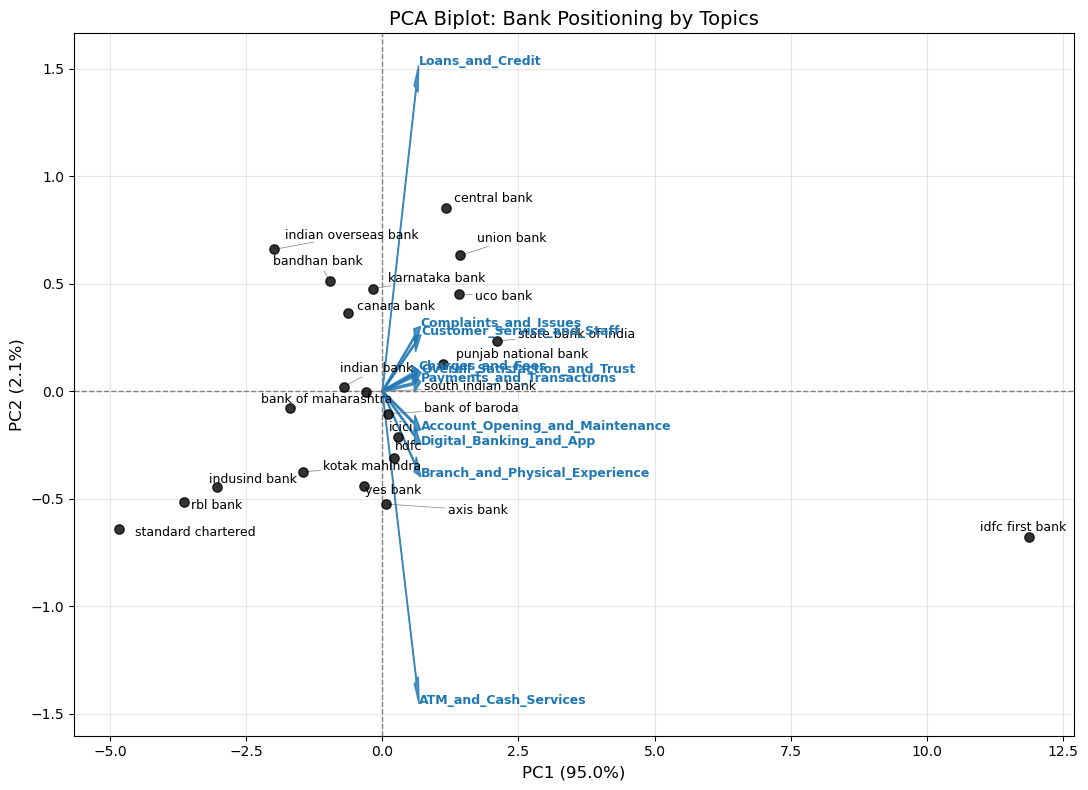

In [127]:
plt.figure(figsize=(11, 8))

# ---- Plot bank scores ----
plt.scatter(
    scores_df['PC1'],
    scores_df['PC2'],
    color='black',
    s=45,
    alpha=0.8,
    zorder=3
)

# Bank labels (with repel)
texts = []
for bank in scores_df.index:
    texts.append(
        plt.text(
            scores_df.loc[bank, 'PC1'],
            scores_df.loc[bank, 'PC2'],
            bank,
            fontsize=9,
            color='black'
        )
    )

# ---- Plot topic arrows ----
arrow_scale = 2.2  # keeps arrows compact & readable

for topic in loadings_df.index:
    plt.arrow(
        0, 0,
        loadings_df.loc[topic, 'PC1'] * arrow_scale,
        loadings_df.loc[topic, 'PC2'] * arrow_scale,
        color='tab:blue',
        alpha=0.8,
        width=0.01,
        head_width=0.08,
        length_includes_head=True,
        zorder=2
    )
    plt.text(
        loadings_df.loc[topic, 'PC1'] * arrow_scale * 1,
        loadings_df.loc[topic, 'PC2'] * arrow_scale * 1,
        topic,
        color='tab:blue',
        fontsize=9,
        fontweight='bold'
    )

# ---- Improve label spacing ----
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color='grey', lw=0.5)
)

# ---- Axes styling ----
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)

plt.title("PCA Biplot: Bank Positioning by Topics", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


PC1 (94.7%) captures the overall sentiment strength across all service dimensions, reflecting general customer satisfaction levels.
PC2 (2.2%) differentiates banks based on operational access experience (ATM/App) versus financial product and fee-related perceptions (Loans, Charges, Credit)

In [66]:
n_factors = 2  # <-- change based on PCA result

fa = FactorAnalyzer(
    n_factors=n_factors,
    rotation='varimax'
)

fa.fit(X_scaled)


FactorAnalyzer(n_factors=2, rotation='varimax', rotation_kwargs={})

**Reasoning**:
The Factor Analysis has been performed, so I will now inspect the factor loadings to understand the relationship between the original topics and the extracted factors.



In [67]:
loadings = pd.DataFrame(
    fa.loadings_,
    index=X.columns,
    columns=[f'Factor_{i+1}' for i in range(n_factors)]
)

loadings


,Factor_1,Factor_2
ATM_and_Cash_Services,0.508083,0.859780
Account_Opening_and_Maintenance,0.729011,0.665577
Branch_and_Physical_Experience,0.708009,0.697216
Charges_and_Fees,0.724707,0.565935
Complaints_and_Issues,0.800867,0.578000
Customer_Service_and_Staff,0.806471,0.587614
Digital_Banking_and_App,0.723249,0.683403
Loans_and_Credit,0.832856,0.452596
Overall_Satisfaction_and_Trust,0.774163,0.626010
Payments_and_Transactions,0.761172,0.628362


In [68]:
factor_scores = fa.transform(X_scaled)

factor_scores = pd.DataFrame(
    factor_scores,
    index=X.index,
    columns=[f'Factor_{i+1}' for i in range(n_factors)]
)

factor_scores


,Factor_1,Factor_2
bank,,
idfc first bank,2.061579,3.538552
state bank of india,0.315617,0.566107
union bank,0.111738,0.365921
uco bank,1.617197,-1.077355
central bank,1.454631,-1.168358
punjab national bank,0.548601,-0.122304
icici,0.855329,-0.650950
hdfc,-0.029057,0.266557
bank of baroda,0.060397,-0.016376


# Factor BiPlot

Factor_1 reflects broad relationship-based and transactional satisfaction, while Factor_2 differentiates banks based on physical and digital access quality.

In [69]:
factor_scores = factor_scores.rename(columns={
    'Factor_1': 'Overall Customer Experience',
    'Factor_2': 'Service Channel & Access Experience'
})


In [70]:
factor_scores

,Overall Customer Experience,Service Channel & Access Experience
bank,,
idfc first bank,2.061579,3.538552
state bank of india,0.315617,0.566107
union bank,0.111738,0.365921
uco bank,1.617197,-1.077355
central bank,1.454631,-1.168358
punjab national bank,0.548601,-0.122304
icici,0.855329,-0.650950
hdfc,-0.029057,0.266557
bank of baroda,0.060397,-0.016376


In [71]:
# Assuming 3 is the optimal number of clusters from the elbow/silhouette method
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)

# X contains the factor_scores.values (the data for clustering)
clusters = kmeans.fit_predict(X)

# Add the cluster labels to the factor_scores DataFrame
factor_scores['cluster'] = clusters

cluster_summary = (
    factor_scores
    .groupby('cluster')[[
        'Overall Customer Experience',
        'Service Channel & Access Experience'
    ]]
    .mean()
)

cluster_summary

,Overall Customer Experience,Service Channel & Access Experience
cluster,,
0,-1.052254,-0.171362
1,2.061579,3.538552
2,0.283463,-0.167359


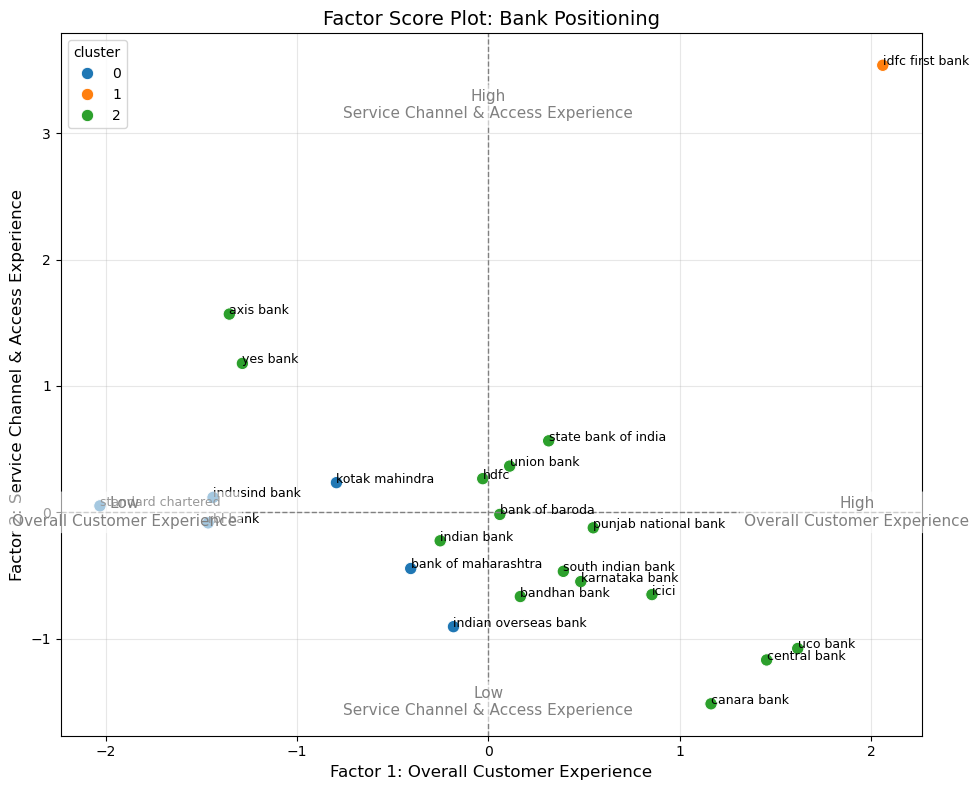

In [72]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=factor_scores,
    x='Overall Customer Experience',
    y='Service Channel & Access Experience',
    hue='cluster',
    palette='tab10',
    s=80
)

# Bank labels
for bank in factor_scores.index:
    plt.text(
        factor_scores.loc[bank, 'Overall Customer Experience'],
        factor_scores.loc[bank, 'Service Channel & Access Experience'],
        bank,
        fontsize=9
    )

# Reference lines
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

# -----------------------------
# Axis labels and title
# -----------------------------
factor1_name = 'Overall Customer Experience'
factor2_name = 'Service Channel & Access Experience'

plt.xlabel(f"Factor 1: {factor1_name}", fontsize=12)
plt.ylabel(f"Factor 2: {factor2_name}", fontsize=12)
plt.title("Factor Score Plot: Bank Positioning", fontsize=14)

# -----------------------------
# Get axis limits (AFTER plotting)
# -----------------------------
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# -----------------------------
# High / Low region labels
# -----------------------------
bbox_style = dict(
    boxstyle="round,pad=0.3",
    fc="white",
    ec="none",
    alpha=0.6
)

# Horizontal (Factor 1)
plt.text(
    xmax * 0.85, 0,
    "High\n" + factor1_name,
    ha='center', va='center',
    fontsize=11, color='grey',
    bbox=bbox_style
)

plt.text(
    xmin * 0.85, 0,
    "Low\n" + factor1_name,
    ha='center', va='center',
    fontsize=11, color='grey',
    bbox=bbox_style
)

# Vertical (Factor 2)
plt.text(
    0, ymax * 0.85,
    "High\n" + factor2_name,
    ha='center', va='center',
    fontsize=11, color='grey',
    bbox=bbox_style
)

plt.text(
    0, ymin * 0.85,
    "Low\n" + factor2_name,
    ha='center', va='center',
    fontsize=11, color='grey',
    bbox=bbox_style
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

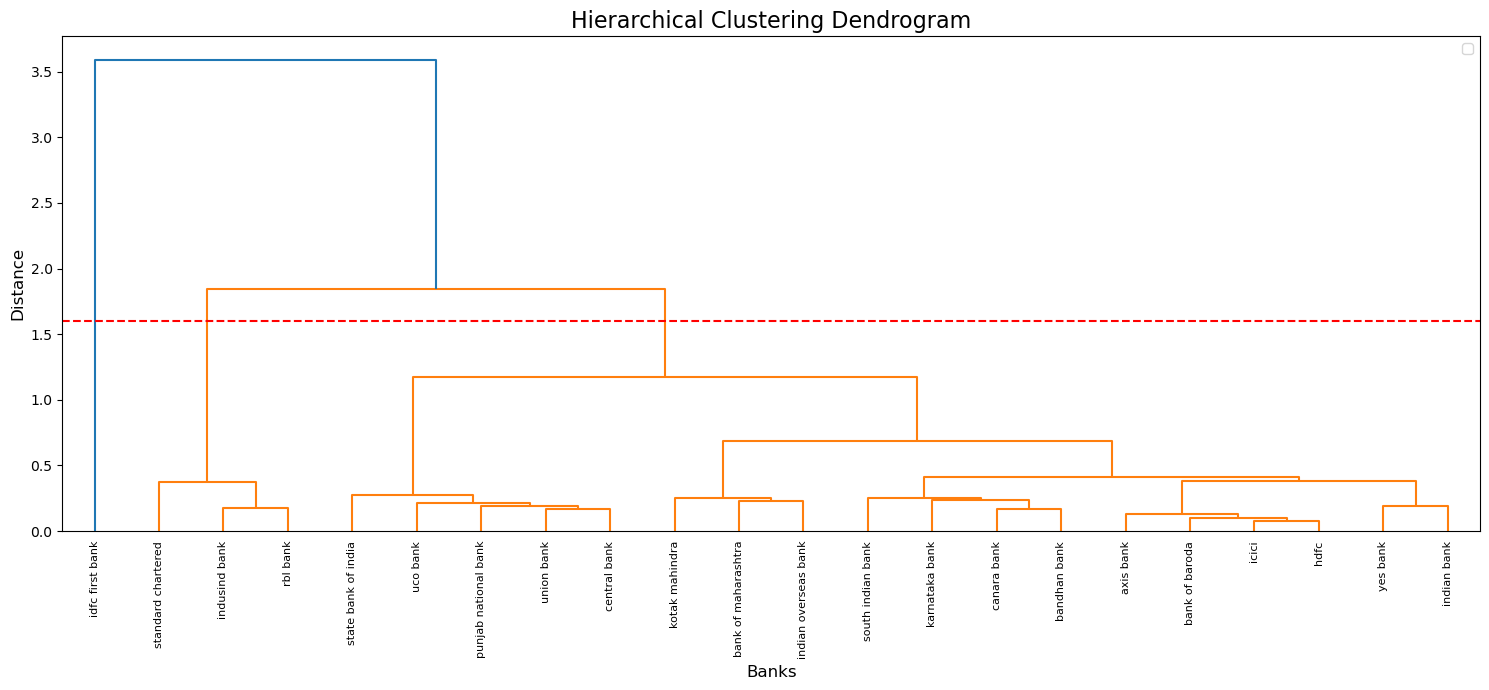

In [73]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# X contains the factor_scores.values (the data for clustering)
# Z was already computed in a previous step
Z = linkage(X, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    labels=factor_scores.index.array # use bank names as labels
)

# Add a horizontal line to indicate the optimal cut for 8 clusters.
# The y-value of the line is chosen visually to intersect 8 vertical lines.
# This might require slight adjustment based on the actual dendrogram output.
plt.axhline(y=1.6, color='r', linestyle='--') # Adjusted y-value for 8 clusters

plt.title('Hierarchical Clustering Dendrogram', fontsize=16)
plt.xlabel('Banks', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

The dendrogram was examined for large linkage distance jumps. A natural separation was observed around a linkage distance of approximately 1.7, indicating the presence of 3–4 meaningful clusters. Therefore, the clustering solution was derived at this cut-off level.

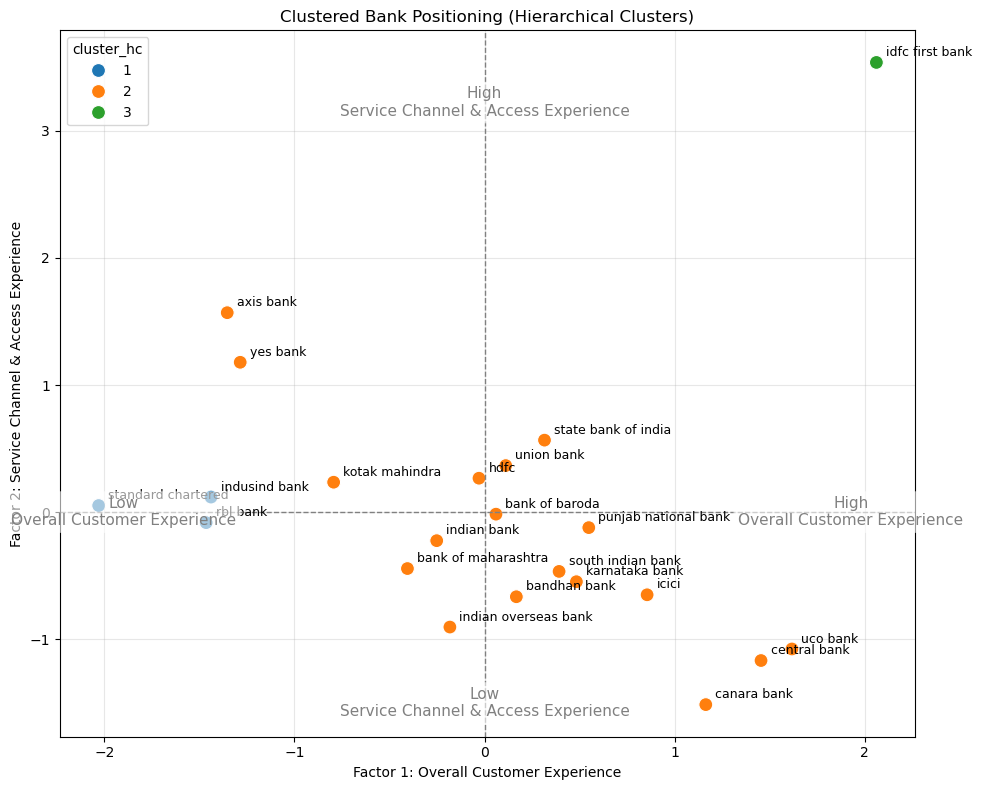

In [131]:

clusters_hc = fcluster(Z, 3, criterion="maxclust")
factor_scores["cluster_hc"] = clusters_hc

# -----------------------------
# Factor axis names (NEW)
# -----------------------------
factor1_col = "Overall Customer Experience"
factor2_col = "Service Channel & Access Experience"

factor1_name = "Overall Customer Experience"
factor2_name = "Service Channel & Access Experience"

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=factor_scores,
    x=factor1_col,
    y=factor2_col,
    hue="cluster_hc",
    palette="tab10",
    s=100,
    legend="full"
)

# Bank labels
for bank in factor_scores.index:
    plt.text(
        factor_scores.loc[bank, factor1_col] + 0.05,
        factor_scores.loc[bank, factor2_col] + 0.05,
        bank,
        fontsize=9
    )

# Reference lines
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.axvline(0, color="grey", linestyle="--", linewidth=1)

# Get axis limits AFTER plotting
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# High/Low region labels
bbox_style = dict(
    boxstyle="round,pad=0.3",
    fc="white",
    ec="none",
    alpha=0.6
)

# Horizontal (Factor 1)
plt.text(
    xmax * 0.85, 0,
    "High\n" + factor1_name,
    ha="center", va="center",
    fontsize=11, color="grey",
    bbox=bbox_style
)
plt.text(
    xmin * 0.85, 0,
    "Low\n" + factor1_name,
    ha="center", va="center",
    fontsize=11, color="grey",
    bbox=bbox_style
)

# Vertical (Factor 2)
plt.text(
    0, ymax * 0.85,
    "High\n" + factor2_name,
    ha="center", va="center",
    fontsize=11, color="grey",
    bbox=bbox_style
)
plt.text(
    0, ymin * 0.85,
    "Low\n" + factor2_name,
    ha="center", va="center",
    fontsize=11, color="grey",
    bbox=bbox_style
)

plt.xlabel(f"Factor 1: {factor1_name}")
plt.ylabel(f"Factor 2: {factor2_name}")
plt.title("Clustered Bank Positioning (Hierarchical Clusters)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [132]:
def create_radar_chart(bank_name, scores, topics):

    # angles
    angles = np.linspace(0, 2*np.pi, len(topics), endpoint=False).tolist()

    # close loop
    scores = np.concatenate((scores, [scores[0]]))
    angles = np.concatenate((angles, [angles[0]]))

    # larger figure
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

    # plot line
    ax.plot(angles, scores, linewidth=2, linestyle='solid', color="#1f77b4")

    # fill area
    ax.fill(angles, scores, color="#1f77b4", alpha=0.25)

    # orientation
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)

    # move labels outward
    ax.tick_params(axis='x', pad=15)

    # readable topic labels
    readable_topics = [t.replace("_", "\n") for t in topics]

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(readable_topics, fontsize=11)

    # radial scale
    ax.set_ylim(-1,1)
    ax.set_yticks([-1,-0.5,0,0.5,1])
    ax.set_yticklabels(["-1","-0.5","0","0.5","1"], fontsize=10)

    # title
    ax.set_title(
        f"Topic Sentiment Profile: {bank_name.title()}",
        fontsize=15,
        pad=25
    )

    # cleaner grid
    ax.grid(True, linestyle="--", alpha=0.6)

    return fig

In [133]:
# Prepare data for radar charts
pivot_avg_sentiment_bank_filled = pivot_avg_sentiment_bank.fillna(0)
topics = pivot_avg_sentiment_bank_filled.columns.tolist()

# Display the head of the filled DataFrame
display(pivot_avg_sentiment_bank_filled.head())

,ATM_and_Cash_Services,Account_Opening_and_Maintenance,Branch_and_Physical_Experience,Charges_and_Fees,Complaints_and_Issues,Customer_Service_and_Staff,Digital_Banking_and_App,Loans_and_Credit,Overall_Satisfaction_and_Trust,Payments_and_Transactions,overall_sentiment
bank,,,,,,,,,,,
axis bank,0.011314,-0.211084,-0.176117,-0.308561,-0.358029,-0.235714,-0.133209,-0.197143,-0.180653,-0.166812,-0.195601
bandhan bank,-0.160984,-0.235780,-0.282195,-0.372619,-0.408774,-0.311245,-0.229197,-0.085581,-0.231792,-0.308568,-0.262673
bank of baroda,-0.069567,-0.188890,-0.215549,-0.253286,-0.304828,-0.217125,-0.174061,-0.190782,-0.184371,-0.141454,-0.193991
bank of maharashtra,-0.203425,-0.344126,-0.291690,-0.232637,-0.384394,-0.334055,-0.305230,-0.322583,-0.345412,-0.352654,-0.311621
canara bank,-0.175160,-0.234494,-0.277908,-0.314565,-0.353742,-0.253945,-0.208238,-0.165463,-0.209572,-0.208406,-0.240149


In [160]:
pivot_avg_sentiment_bank_filled

,ATM_and_Cash_Services,Account_Opening_and_Maintenance,Branch_and_Physical_Experience,Charges_and_Fees,Complaints_and_Issues,Customer_Service_and_Staff,Digital_Banking_and_App,Loans_and_Credit,Overall_Satisfaction_and_Trust,Payments_and_Transactions,overall_sentiment
bank,,,,,,,,,,,
axis bank,0.011314,-0.211084,-0.176117,-0.308561,-0.358029,-0.235714,-0.133209,-0.197143,-0.180653,-0.166812,-0.195601
bandhan bank,-0.160984,-0.235780,-0.282195,-0.372619,-0.408774,-0.311245,-0.229197,-0.085581,-0.231792,-0.308568,-0.262673
bank of baroda,-0.069567,-0.188890,-0.215549,-0.253286,-0.304828,-0.217125,-0.174061,-0.190782,-0.184371,-0.141454,-0.193991
bank of maharashtra,-0.203425,-0.344126,-0.291690,-0.232637,-0.384394,-0.334055,-0.305230,-0.322583,-0.345412,-0.352654,-0.311621
canara bank,-0.175160,-0.234494,-0.277908,-0.314565,-0.353742,-0.253945,-0.208238,-0.165463,-0.209572,-0.208406,-0.240149
central bank,-0.127629,-0.136499,-0.187109,-0.107125,-0.225579,-0.114477,-0.096012,-0.000742,-0.107678,-0.133193,-0.123604
hdfc,-0.020492,-0.179487,-0.189299,-0.290047,-0.318637,-0.210241,-0.133548,-0.183582,-0.150025,-0.185032,-0.186039
icici,-0.065107,-0.155026,-0.162819,-0.254281,-0.297895,-0.210285,-0.158114,-0.200366,-0.135723,-0.176381,-0.181600
idfc first bank,0.702237,0.645230,0.534702,0.493762,0.324320,0.541668,0.669002,0.448356,0.805057,0.607752,0.577209


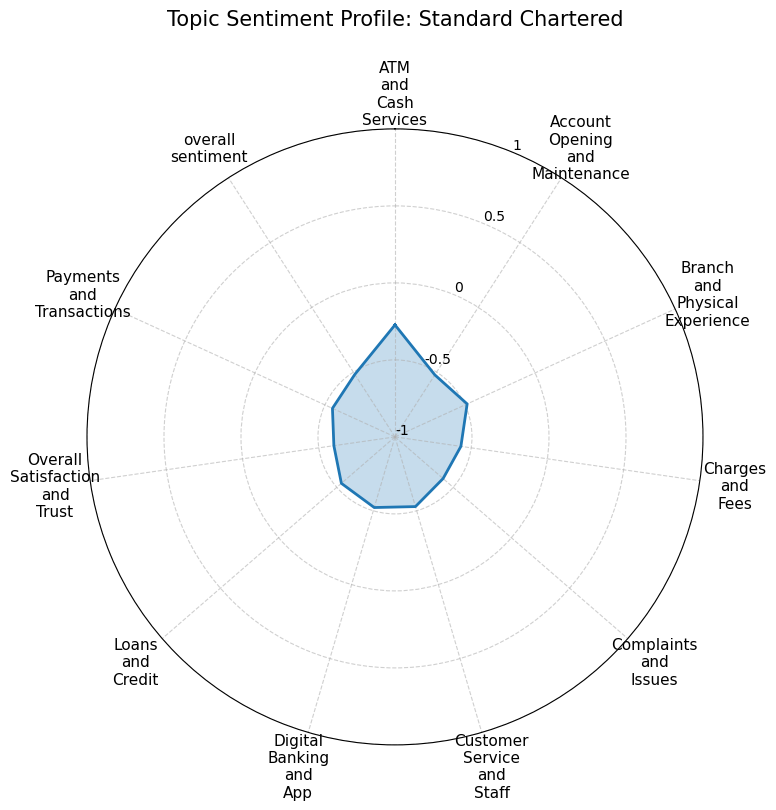

In [165]:
bank_name = 'standard chartered'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

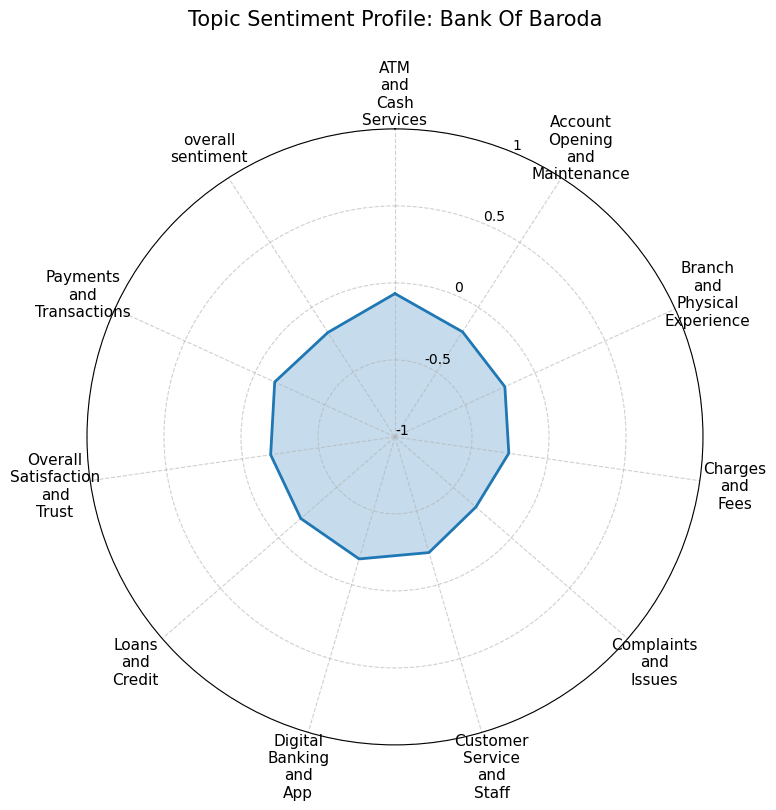

In [135]:
bank_name = 'bank of baroda'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

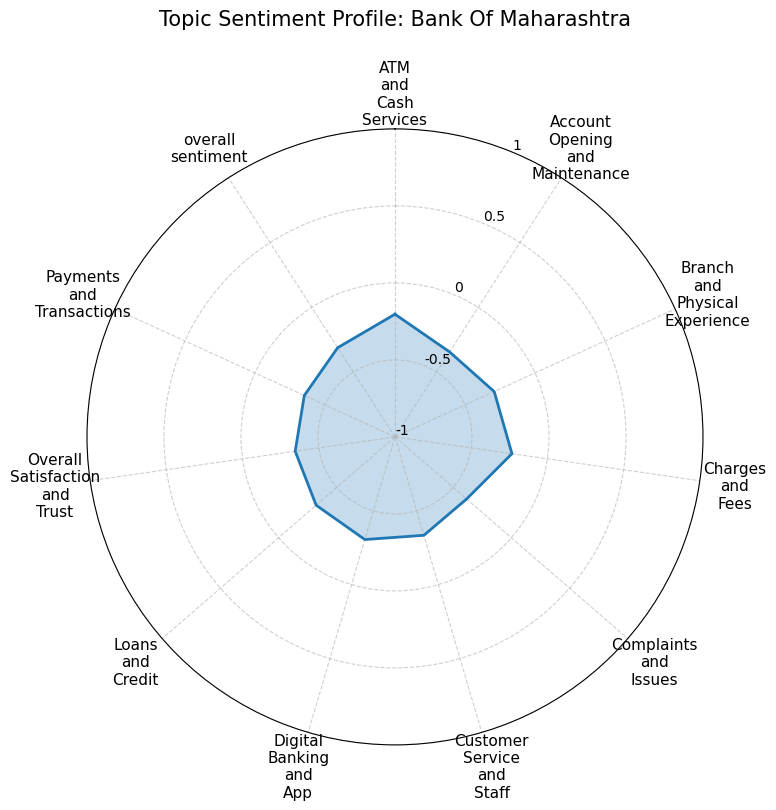

In [136]:
bank_name = 'bank of maharashtra'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

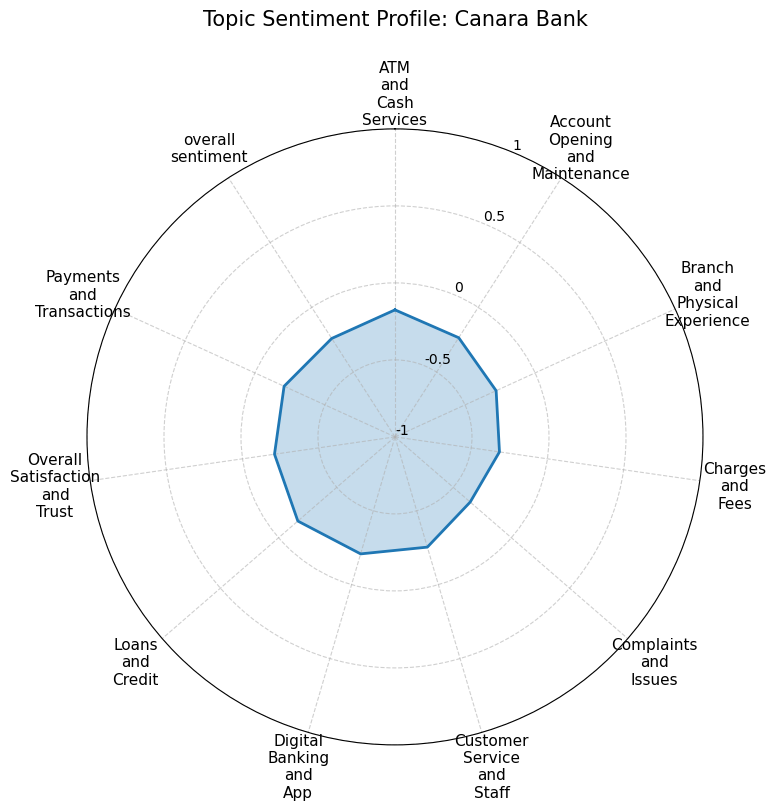

In [137]:
bank_name = 'canara bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

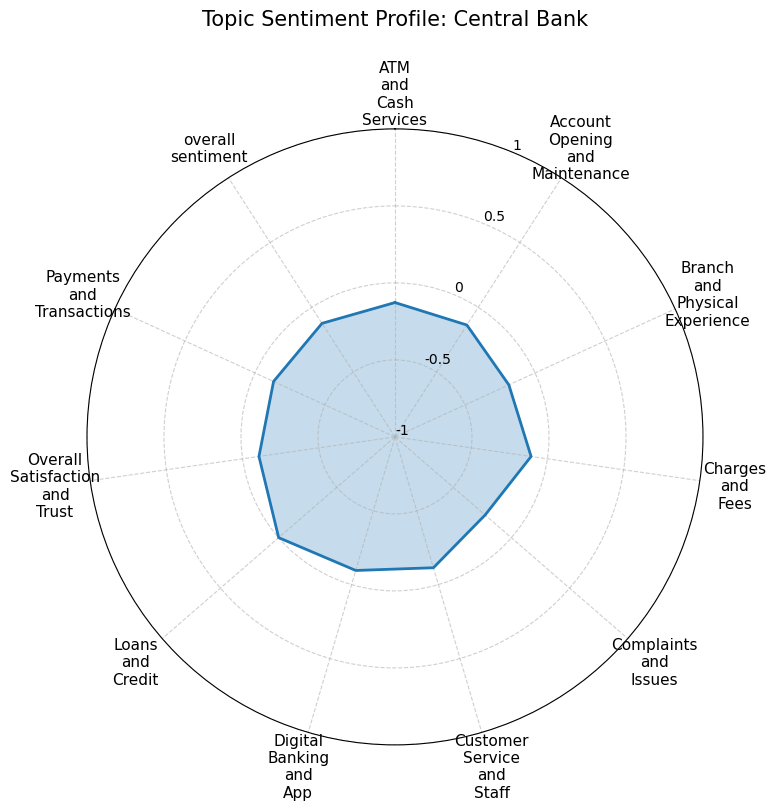

In [138]:
bank_name = 'central bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

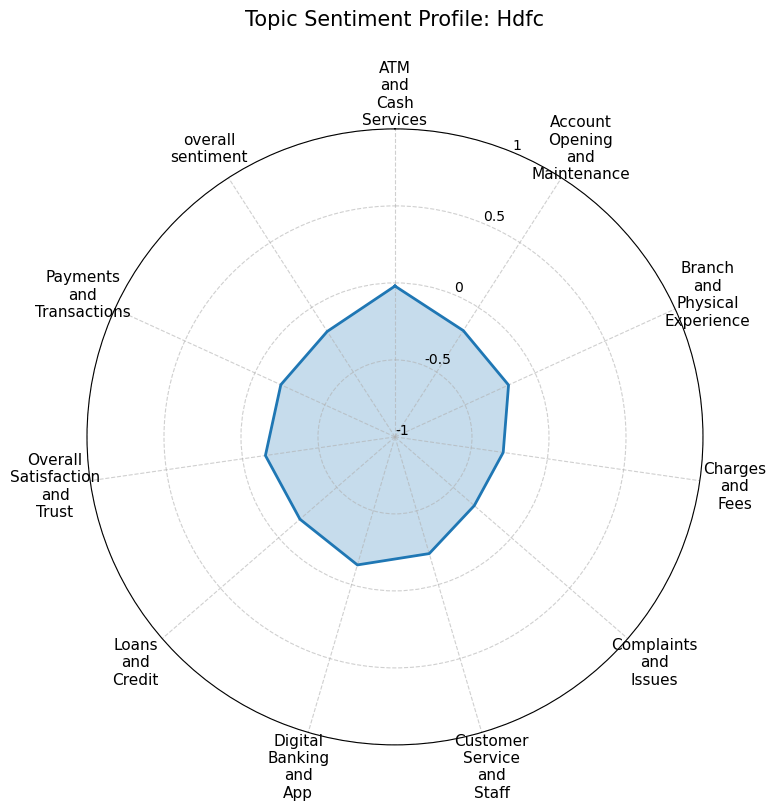

In [139]:
bank_name = 'hdfc'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

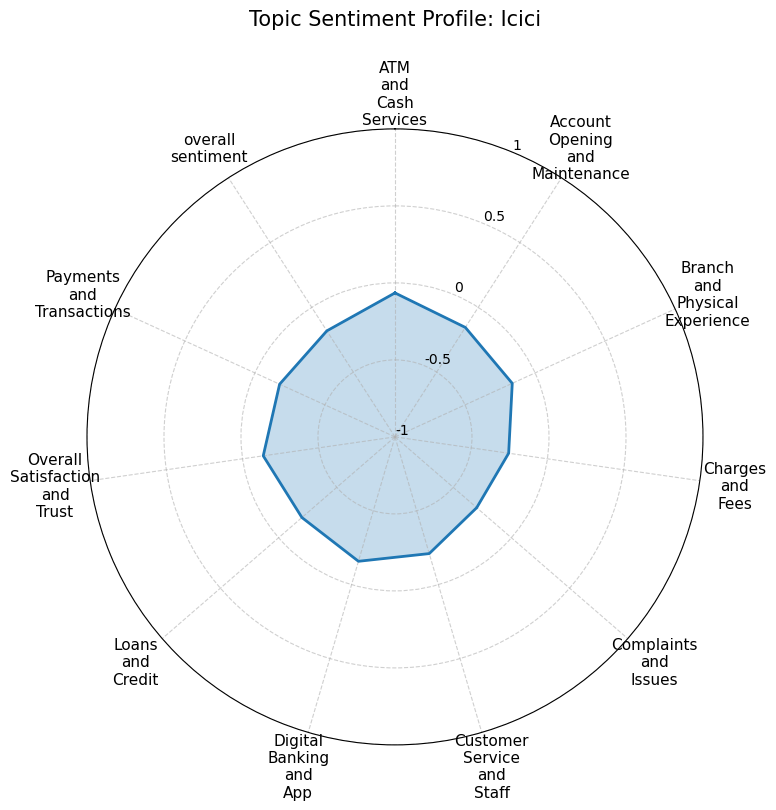

In [140]:
bank_name = 'icici'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

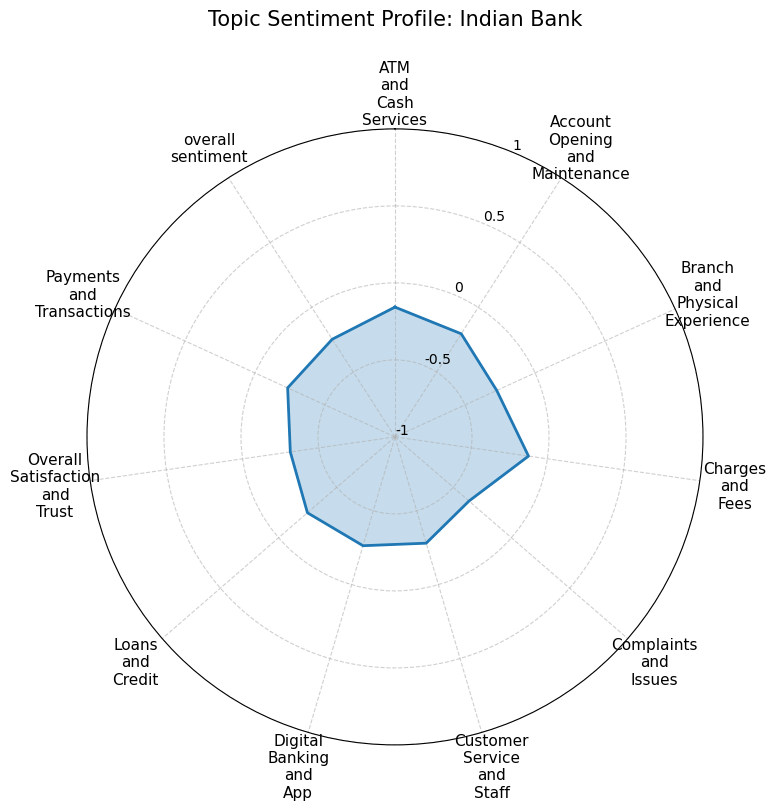

In [141]:
bank_name = 'indian bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

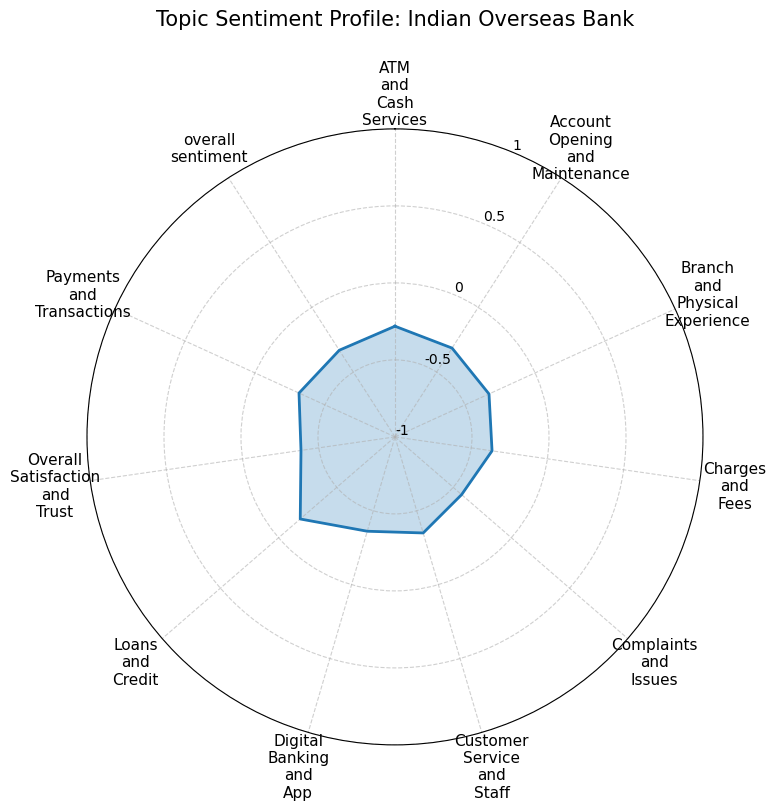

In [142]:
bank_name = 'indian overseas bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

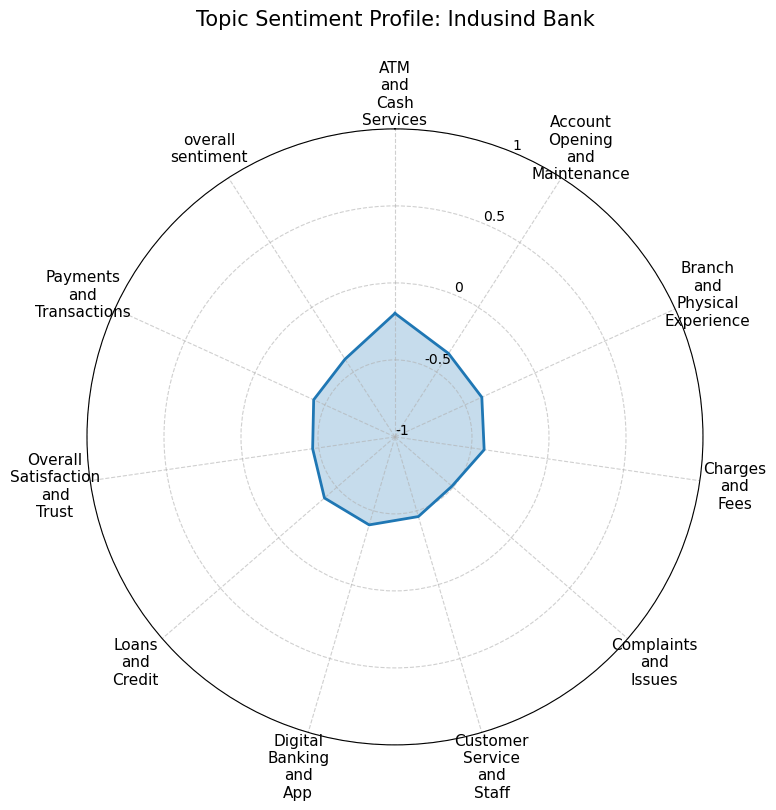

In [143]:
bank_name = 'indusind bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

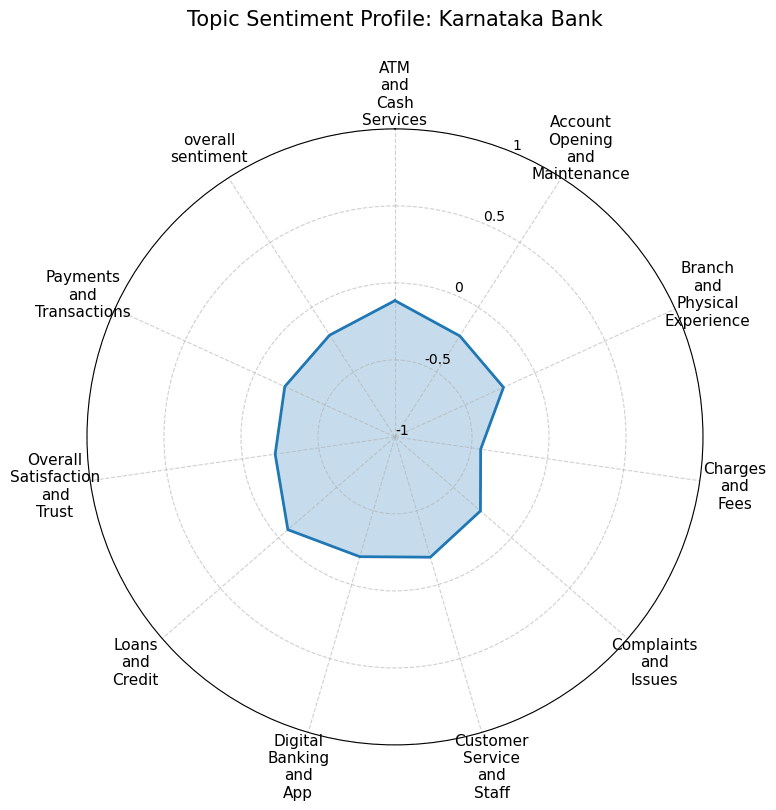

In [144]:
bank_name = 'karnataka bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

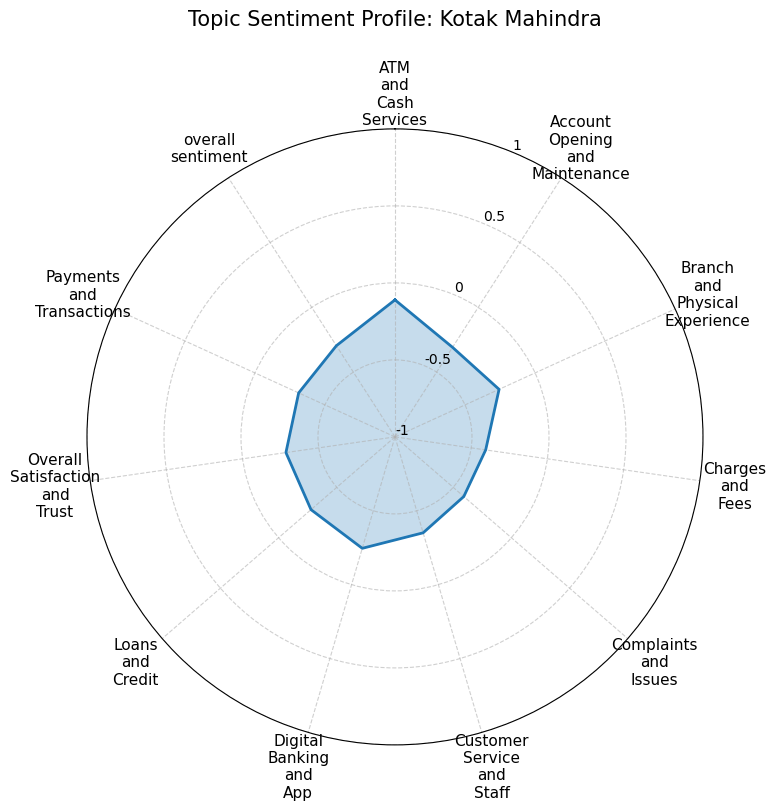

In [145]:
bank_name = 'kotak mahindra'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

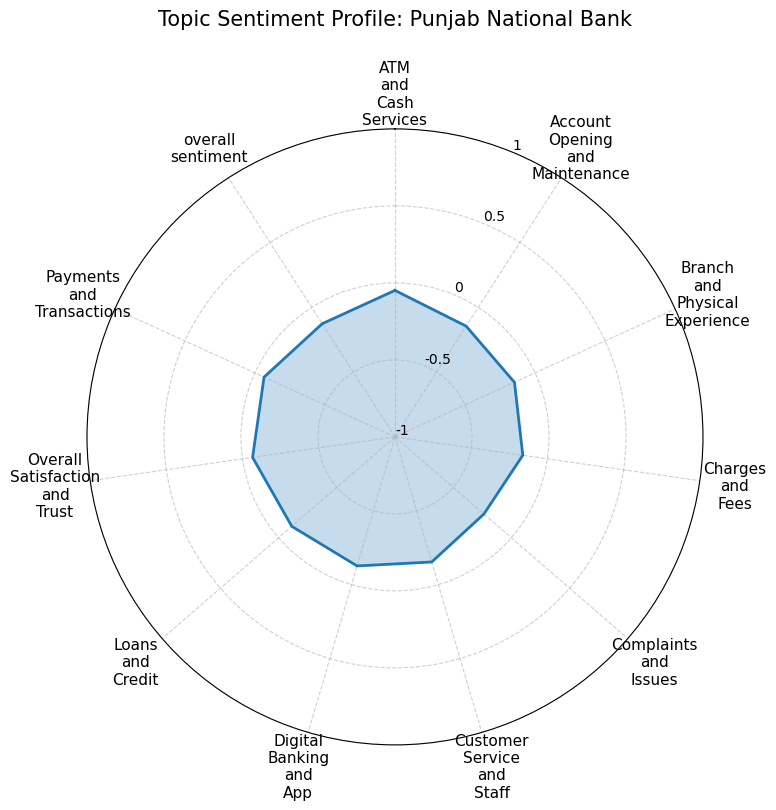

In [146]:
bank_name = 'punjab national bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

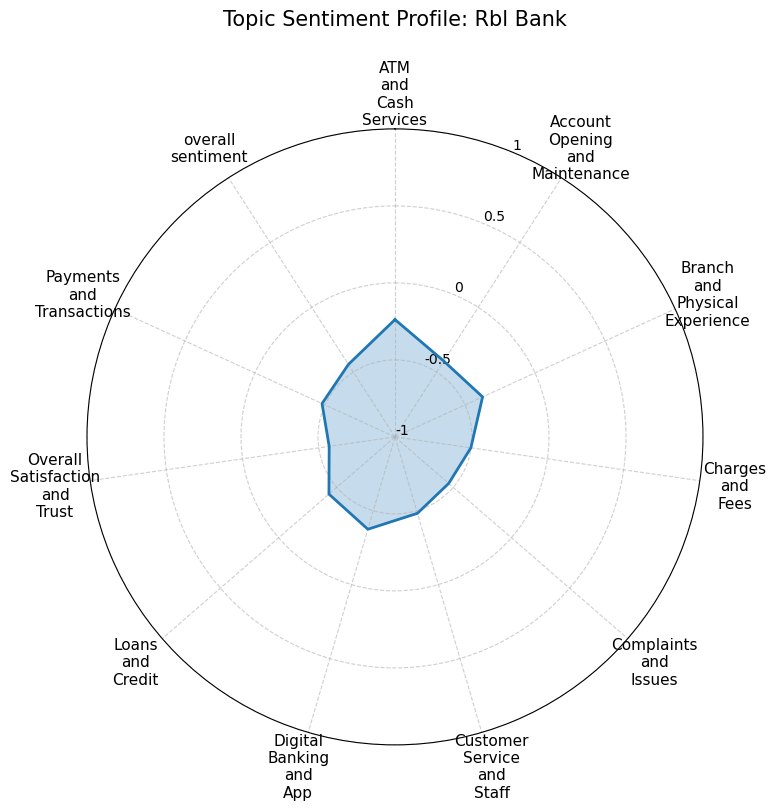

In [147]:
bank_name = 'rbl bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

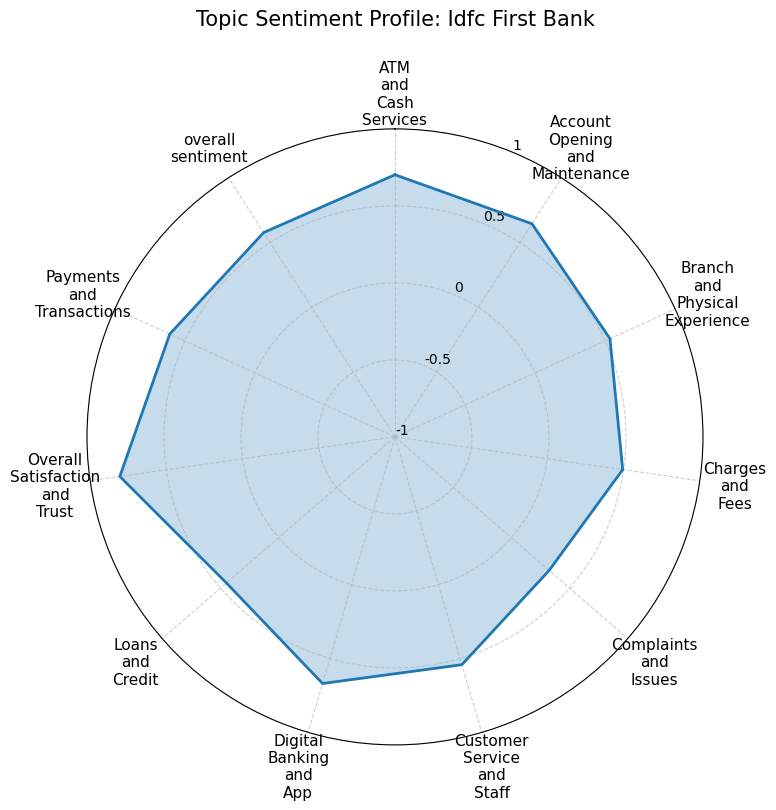

In [157]:
bank_name = 'idfc first bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

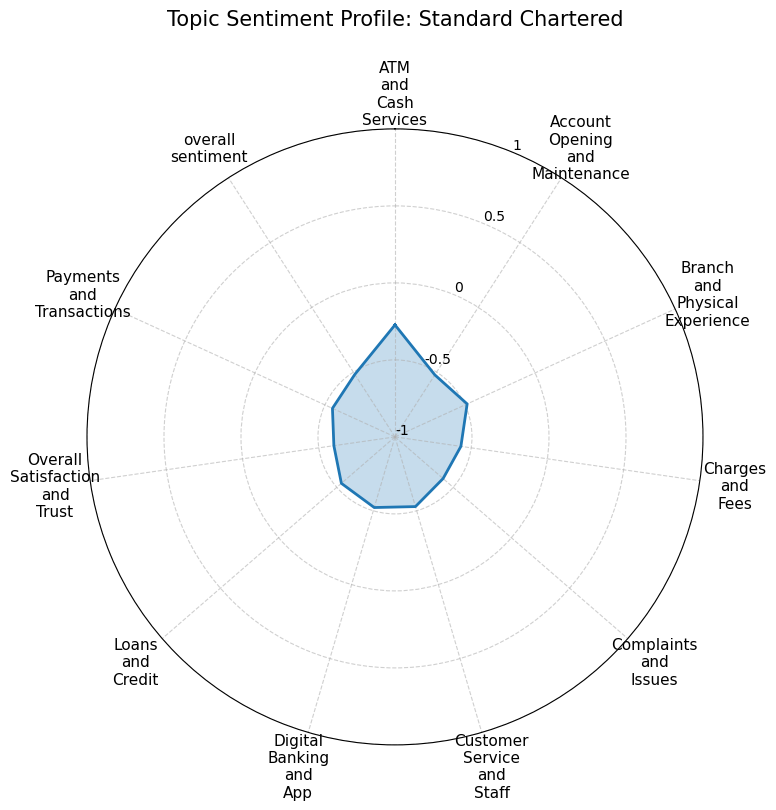

In [149]:
bank_name = 'standard chartered'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

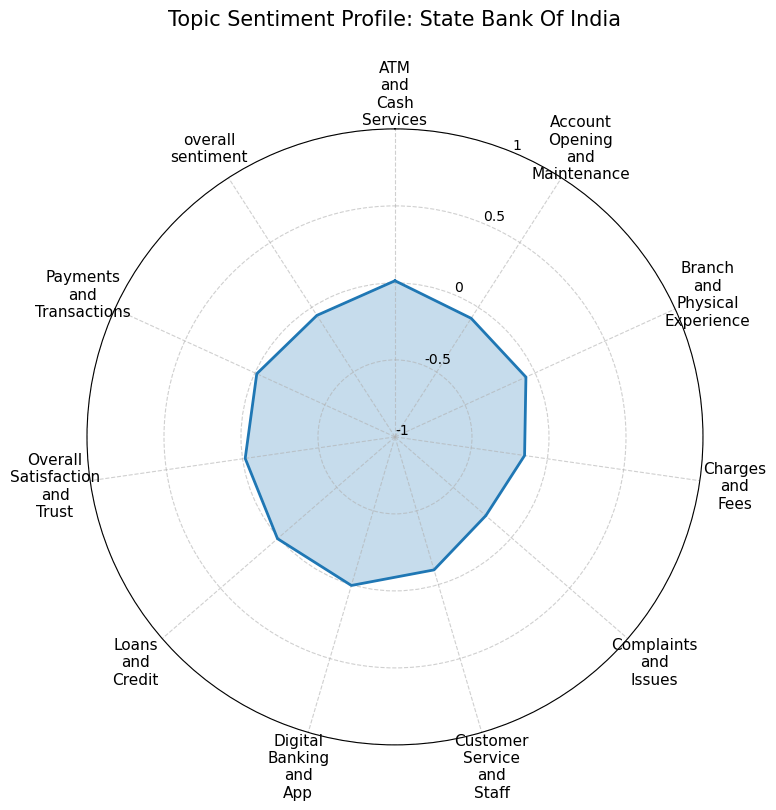

In [150]:
bank_name = 'state bank of india'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

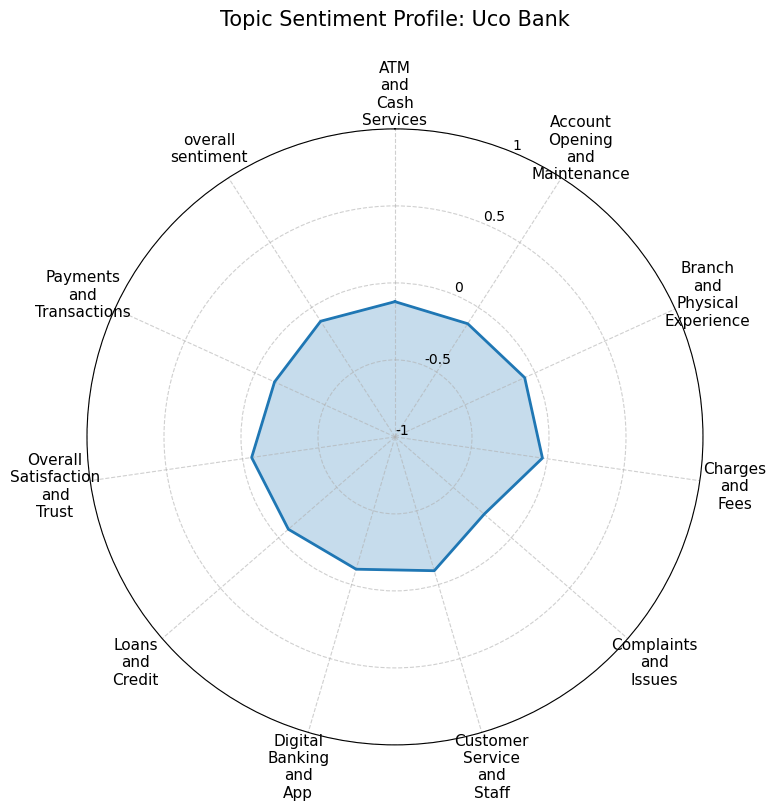

In [151]:
bank_name = 'uco bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

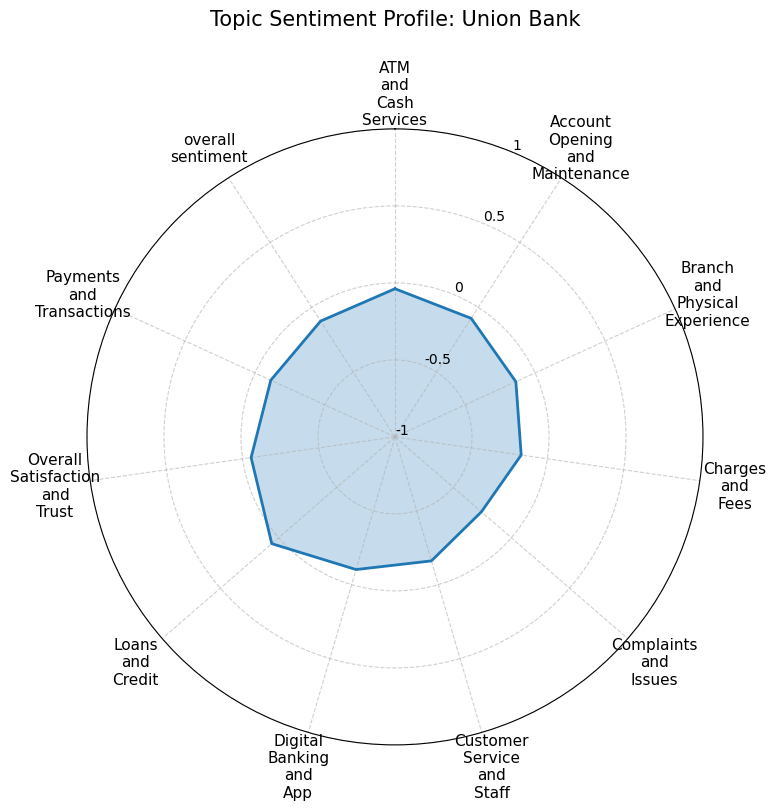

In [152]:
bank_name = 'union bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

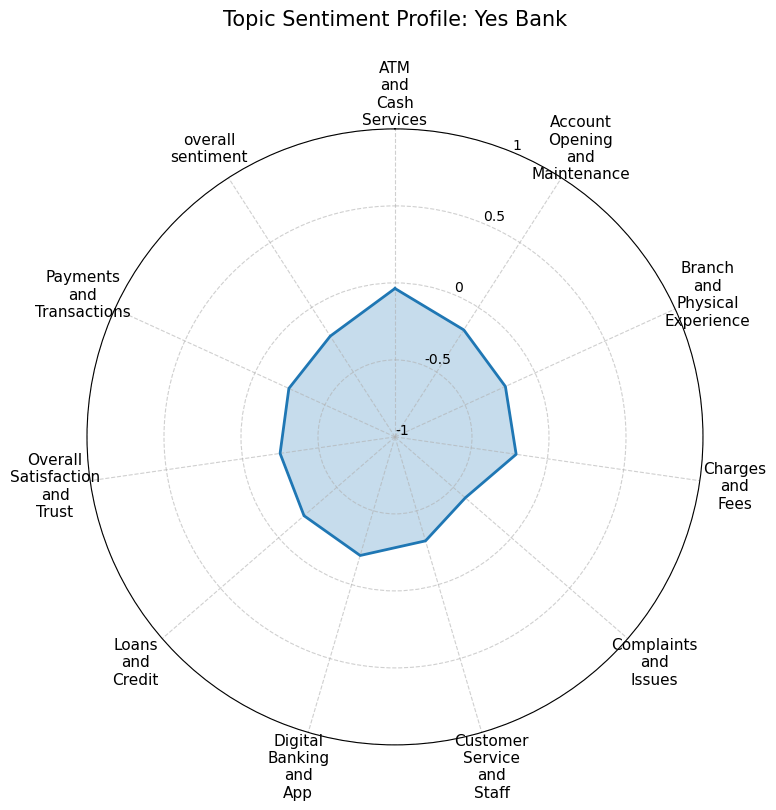

In [153]:
bank_name = 'yes bank'
scores = pivot_avg_sentiment_bank_filled.loc[bank_name, topics].values
fig = create_radar_chart(bank_name, scores, topics)

plt.show(fig)

sentiment_class
Positive     4306
Neutral      2682
Negative    10526
Name: count, dtype: int64


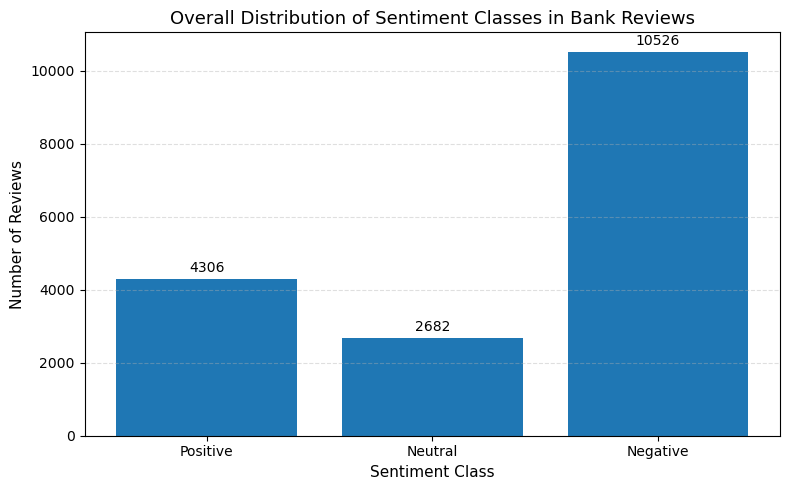

In [154]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Sentiment class creation (if needed)
# -----------------------------------
# Your notebook uses review-level mean sentiment scores.
# This block creates sentiment classes only if they do not already exist.

if "sentiment_class" not in review_level.columns:
    review_level["sentiment_class"] = review_level["review_sentiment_mean"].apply(
        lambda x: "Positive" if x > 0.2 else ("Negative" if x < -0.2 else "Neutral")
    )

# -----------------------------------
# Count sentiment classes
# -----------------------------------
sentiment_counts = (
    review_level["sentiment_class"]
    .value_counts()
    .reindex(["Positive", "Neutral", "Negative"], fill_value=0)
)

print(sentiment_counts)

# -----------------------------------
# Plot: Overall sentiment distribution
# -----------------------------------
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Overall Distribution of Sentiment Classes in Bank Reviews", fontsize=13)
plt.xlabel("Sentiment Class", fontsize=11)
plt.ylabel("Number of Reviews", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(sentiment_counts.values) * 0.01,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

bank
idfc first bank         0.597347
state bank of india    -0.066968
uco bank               -0.094013
central bank           -0.141976
punjab national bank   -0.151782
union bank             -0.164229
icici                  -0.207976
hdfc                   -0.220112
bank of baroda         -0.230706
axis bank              -0.252678
karnataka bank         -0.259830
canara bank            -0.267203
bandhan bank           -0.291384
south indian bank      -0.291412
yes bank               -0.298275
indian bank            -0.333467
bank of maharashtra    -0.335567
kotak mahindra         -0.347575
indian overseas bank   -0.376842
indusind bank          -0.462280
rbl bank               -0.507286
standard chartered     -0.556264
Name: review_sentiment_mean, dtype: float64


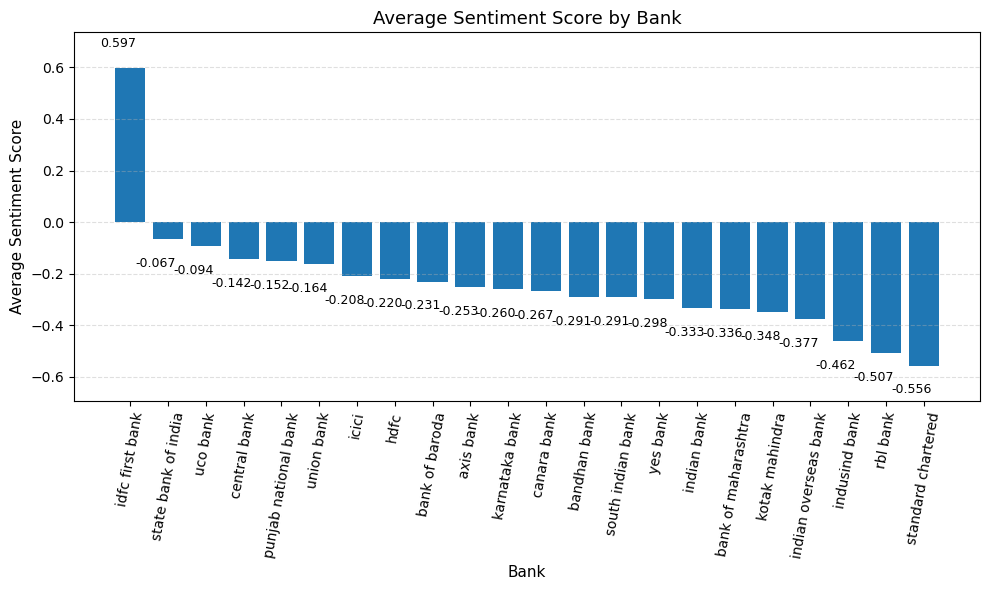

In [155]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Average sentiment score by bank
# -----------------------------------
bank_sentiment = (
    review_level
    .groupby("bank")["review_sentiment_mean"]
    .mean()
    .sort_values(ascending=False)
)

print(bank_sentiment)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(10, 6))

bars = plt.bar(
    bank_sentiment.index,
    bank_sentiment.values
)

plt.title("Average Sentiment Score by Bank", fontsize=13)
plt.xlabel("Bank", fontsize=11)
plt.ylabel("Average Sentiment Score", fontsize=11)
plt.xticks(rotation=80)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# -----------------------------------
# Adaptive offset for value labels
# -----------------------------------
y_min = bank_sentiment.min()
y_max = bank_sentiment.max()
y_range = y_max - y_min

# fallback in case all values are identical
if y_range == 0:
    y_range = 0.05

offset = y_range * 0.06

for bar in bars:
    height = bar.get_height()

    # Place label above positive bars, below negative bars
    if height >= 0:
        y_text = height + offset
        va = "bottom"
    else:
        y_text = height - offset
        va = "top"

    plt.text(
        bar.get_x() + bar.get_width() / 10,
        y_text,
        f"{height:.3f}",
        ha="center",
        va=va,
        fontsize=9
    )

# Adjust y-limits so labels don't get cut off
plt.ylim(y_min - 2 * offset, y_max + 2 * offset)

plt.tight_layout()
plt.show()

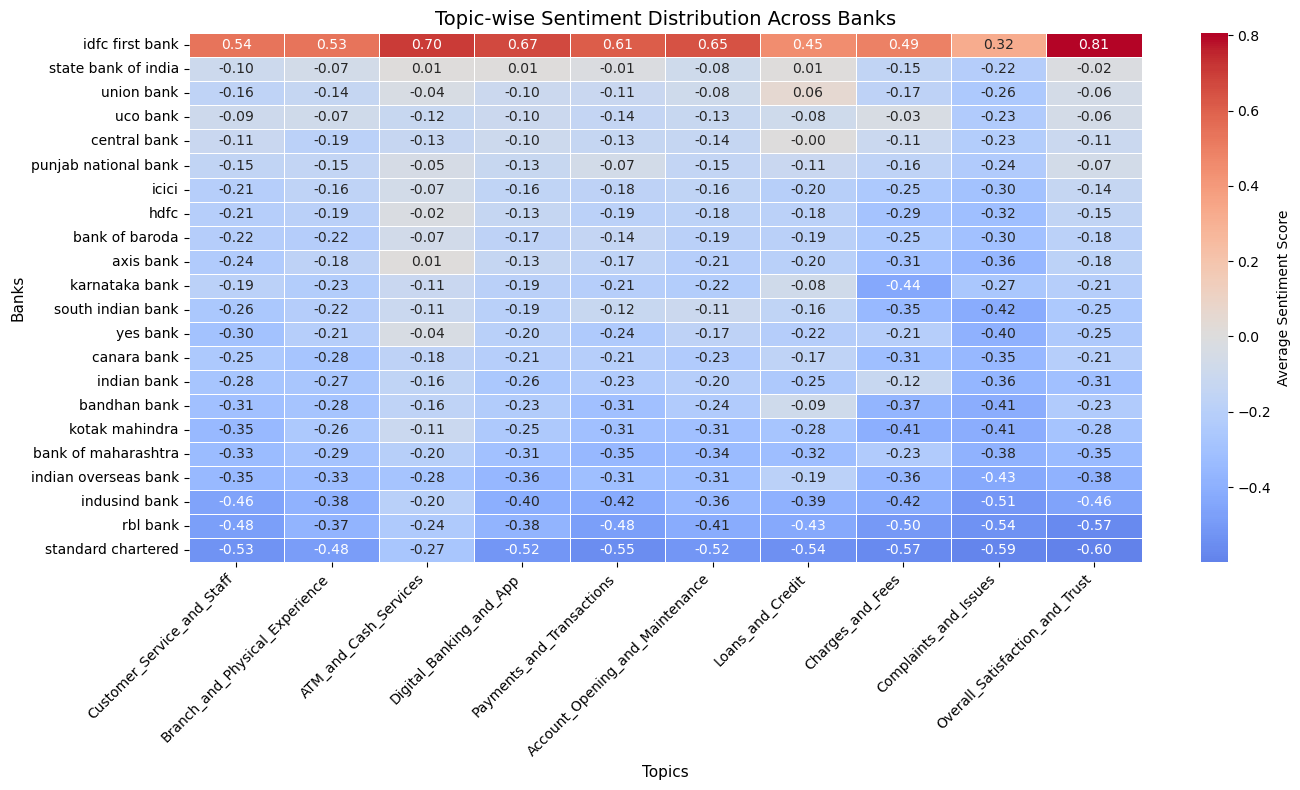

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1. Pick the correct sentiment score column
# -------------------------------------------------
if "final_sentiment_score" in review_level.columns:
    score_col = "final_sentiment_score"
elif "review_sentiment_mean" in review_level.columns:
    score_col = "review_sentiment_mean"
else:
    raise ValueError("No sentiment score column found in review_level.")

# -------------------------------------------------
# 2. Pick the correct topic column
# -------------------------------------------------
# Change this only if your topic column has a different name
if "topics" in review_level.columns:
    topic_col = "topics"
elif "topic" in review_level.columns:
    topic_col = "topic"
elif "topic_list" in review_level.columns:
    topic_col = "topic_list"
else:
    raise ValueError("No topic column found in review_level.")

# -------------------------------------------------
# 3. Convert topic column into list format
# -------------------------------------------------
def to_topic_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(",") if i.strip()]

heatmap_df = review_level.copy()
heatmap_df["topic_list"] = heatmap_df[topic_col].apply(to_topic_list)

# -------------------------------------------------
# 4. Explode topics so each review-topic is one row
# -------------------------------------------------
heatmap_long = heatmap_df.explode("topic_list").copy()
heatmap_long = heatmap_long[heatmap_long["topic_list"].notna()]
heatmap_long = heatmap_long[heatmap_long["topic_list"] != ""]

# -------------------------------------------------
# 5. Compute average sentiment score by bank and topic
# -------------------------------------------------
bank_topic_sentiment = (
    heatmap_long
    .groupby(["bank", "topic_list"])[score_col]
    .mean()
    .unstack()
)

# -------------------------------------------------
# 6. Optional: reorder topic columns to match your report
# -------------------------------------------------
desired_order = [
    "Customer_Service_and_Staff",
    "Branch_and_Physical_Experience",
    "ATM_and_Cash_Services",
    "Digital_Banking_and_App",
    "Payments_and_Transactions",
    "Account_Opening_and_Maintenance",
    "Loans_and_Credit",
    "Charges_and_Fees",
    "Complaints_and_Issues",
    "Overall_Satisfaction_and_Trust"
]

existing_cols = [col for col in desired_order if col in bank_topic_sentiment.columns]
remaining_cols = [col for col in bank_topic_sentiment.columns if col not in existing_cols]
bank_topic_sentiment = bank_topic_sentiment[existing_cols + remaining_cols]

# -------------------------------------------------
# 7. Optional: sort banks by overall average topic sentiment
# -------------------------------------------------
bank_topic_sentiment["overall_mean"] = bank_topic_sentiment.mean(axis=1)
bank_topic_sentiment = bank_topic_sentiment.sort_values("overall_mean", ascending=False)
bank_topic_sentiment = bank_topic_sentiment.drop(columns="overall_mean")

# -------------------------------------------------
# 8. Plot heatmap
# -------------------------------------------------
plt.figure(figsize=(14, 8))

sns.heatmap(
    bank_topic_sentiment,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Average Sentiment Score"}
)

plt.title("Topic-wise Sentiment Distribution Across Banks", fontsize=14)
plt.xlabel("Topics", fontsize=11)
plt.ylabel("Banks", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()